In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.animation as animation
import datetime
import seaborn as sns
import missingno as msno
import firebase_admin
from firebase_admin import credentials, db
from datetime import datetime  # Untuk konversi timestamp ke human-readable
sns.set_theme(style="whitegrid")
%matplotlib inline 

In [2]:
# Konfigurasi database sumber
source_cred = credentials.Certificate("D:/staklimjerukagung-firebase-adminsdk-kcfma-e091165a9b.json")
firebase_admin.initialize_app(source_cred, {
    'databaseURL': 'https://staklimjerukagung-default-rtdb.asia-southeast1.firebasedatabase.app/'
})

In [4]:
station_ids = ['id-03','id-05']
# Input readable date
start_readable_date = "01-01-2025 00:00:00"  # Format: DD-MM-YYYY HH:MM:SS
end_readable_date = "31-12-2026 23:59:59"  # Format: DD-MM-YYYY HH:MM:SS

# Convert readable date to Unix timestamp
start_timestamp = int(datetime.strptime(start_readable_date, "%d-%m-%Y %H:%M:%S").timestamp())
print(start_timestamp) # Convert to string and print
end_timestamp = int(datetime.strptime(end_readable_date, "%d-%m-%Y %H:%M:%S").timestamp())
print(end_timestamp) # Convert to string and print


1735664400
1798736399


In [4]:
def fetch_weather_data(station_id, start_ts, end_ts):
    try:
        # Membuat path referensi secara dinamis berdasarkan station_id
        ref_path = f'/auto_weather_stat/{station_id}/data'
        ref_data = db.reference(ref_path)

        # Membuat query dengan rentang waktu
        query_data = ref_data.order_by_key().start_at(str(start_ts)).end_at(str(end_ts))

        # Mengambil dan mengembalikan hasil
        results = query_data.get()
        print(f"Data untuk stasiun {station_id} berhasil diambil.")
        return results
    except Exception as e:
        print(f"Terjadi error saat mengambil data untuk {station_id}: {e}")
        return None

# 3. Gunakan loop untuk mengambil data semua stasiun dan simpan hasilnya
all_weather_data = {}
for station in station_ids:
    # Panggil fungsi untuk setiap stasiun
    data = fetch_weather_data(station, start_timestamp, end_timestamp)
    if data:
        all_weather_data[station] = data

Data untuk stasiun id-03 berhasil diambil.
Data untuk stasiun id-05 berhasil diambil.


In [5]:
def create_weather_dataframe(data_dict, source_name):
    # Periksa apakah ada data untuk diproses
    if not data_dict:
        print(f"Tidak ada data dari sumber '{source_name}' untuk diproses.")
        return None

    try:
        # Mengubah data dari dictionary menjadi DataFrame
        # 'orient="index"' menjadikan key dari dictionary sebagai baris awal
        df = pd.DataFrame.from_dict(data_dict, orient='index')

        # Memastikan kolom 'timestamp' ada.
        # Jika 'timestamp' bukan salah satu kolom, berarti ia adalah indeks.
        if 'timestamp' not in df.columns:
            df.index.name = 'timestamp'  # Beri nama pada indeks
            df.reset_index(inplace=True) # Pindahkan indeks menjadi kolom biasa

        print(f"DataFrame untuk sumber '{source_name}' berhasil dibuat.")
        return df
        
    except Exception as e:
        print(f"Gagal membuat DataFrame untuk '{source_name}': {e}")
        return None


# 2. Siapkan dictionary kosong untuk menampung DataFrame yang akan kita buat
weather_dataframes = {}

# 3. Loop melalui setiap item di all_weather_data
#    Gunakan .items() untuk mendapatkan key (nama stasiun) dan value (datanya)
for station_id, raw_data in all_weather_data.items():
    
    # Panggil fungsi baru kita untuk mengubah data mentah menjadi DataFrame
    df = create_weather_dataframe(raw_data, station_id)
    
    # Jika DataFrame berhasil dibuat, simpan ke dalam dictionary kita
    if df is not None:
        weather_dataframes[station_id] = df

DataFrame untuk sumber 'id-03' berhasil dibuat.
DataFrame untuk sumber 'id-05' berhasil dibuat.


In [6]:
def save_weather_data(data_dict, output_folder='weather_data_sensor'):
    # Pastikan modul os terimport (biasanya sudah di cell paling atas, tapi untuk keamanan)
    import os

    # Buat folder jika belum ada
    if not os.path.exists(output_folder):
        try:
            os.makedirs(output_folder)
            print(f"Folder '{output_folder}' berhasil dibuat.")
        except OSError as e:
            print(f"Gagal membuat folder '{output_folder}': {e}")
            return

    print(f"\n--- Menyimpan Data ke Folder '{output_folder}' ---")

    for station_id, df in data_dict.items():
        try:
            # Buat nama file yang aman
            filename = f"weather_data_{station_id}.csv"
            file_path = os.path.join(output_folder, filename)

            # Simpan ke CSV
            # index=False karena timestamp biasanya sudah di-reset menjadi kolom di langkah sebelumnya
            df.to_csv(file_path, index=False)
            print(f"Berhasil menyimpan: {filename}")
        except Exception as e:
            print(f"Gagal menyimpan data untuk {station_id}: {e}")

# Panggil fungsi untuk menyimpan data
save_weather_data(weather_dataframes)


--- Menyimpan Data ke Folder 'weather_data_sensor' ---
Berhasil menyimpan: weather_data_id-03.csv
Berhasil menyimpan: weather_data_id-05.csv


In [5]:
def load_weather_data(input_folder='weather_data_sensor'):
    loaded_data = {}

    # Cek apakah folder ada
    if not os.path.exists(input_folder):
        print(f"Folder '{input_folder}' tidak ditemukan.")
        return loaded_data

    print(f"\n--- Membaca Data dari Folder '{input_folder}' ---")

    try:
        # Loop semua file di folder
        for filename in os.listdir(input_folder):
            if filename.endswith(".csv") and filename.startswith("weather_data_"):
                # Ekstrak station_id dari nama file (weather_data_id-03.csv -> id-03)
                station_id = filename.replace("weather_data_", "").replace(".csv", "")
                
                file_path = os.path.join(input_folder, filename)
                
                # Baca CSV ke DataFrame
                df = pd.read_csv(file_path)
                
                # Simpan ke dictionary
                loaded_data[station_id] = df
                print(f"Berhasil memuat: {station_id} ({len(df)} baris)")
                
        return loaded_data

    except Exception as e:
        print(f"Terjadi kesalahan saat membaca data: {e}")
        return {}


# Uncomment baris di bawah ini jika ingin me-load data dari CSV menggantikan data dari API
weather_dataframes = load_weather_data()


--- Membaca Data dari Folder 'weather_data_sensor' ---
Berhasil memuat: id-03 (761543 baris)
Berhasil memuat: id-05 (710362 baris)


In [6]:
for st_id in station_ids:
    if st_id in weather_dataframes:
        print(f"\nMenampilkan 5 baris pertama dari DataFrame '{st_id}':")
        weather_dataframes[st_id].tail(10)


Menampilkan 5 baris pertama dari DataFrame 'id-03':

Menampilkan 5 baris pertama dari DataFrame 'id-05':


In [7]:
def convert_timestamp_to_int(df, column_name='timestamp'):
    """
    Mengubah tipe data kolom tertentu dalam DataFrame menjadi integer.

    Args:
        df (pd.DataFrame): DataFrame yang akan dimodifikasi.
        column_name (str): Nama kolom yang akan diubah tipenya. Defaultnya adalah 'timestamp'.

    Returns:
        pd.DataFrame: DataFrame yang telah dimodifikasi, atau DataFrame asli jika kolom tidak ditemukan.
    """
    # Periksa apakah input adalah DataFrame yang valid dan memiliki kolom yang dimaksud
    if isinstance(df, pd.DataFrame) and column_name in df.columns:
        try:
            df[column_name] = df[column_name].astype(int)
            print(f"Kolom '{column_name}' berhasil diubah menjadi tipe integer.")
        except Exception as e:
            print(f"Gagal mengubah tipe data kolom '{column_name}': {e}")
    else:
        # Memberi tahu pengguna jika kolom tidak ada di DataFrame
        print(f"Peringatan: Kolom '{column_name}' tidak ditemukan dalam DataFrame.")
        
    return df



In [8]:
# ==============================================================================
# PERBAIKAN: HANDLING MISSING VALUES PADA TIMESTAMP
# ==============================================================================

for station_id in weather_dataframes:
    print(f"🔄 Memproses DataFrame untuk stasiun: {station_id}")
    
    # Ambil dataframe sementara
    df_temp = weather_dataframes[station_id]
    
    # 1. CEK & HAPUS TIMESTAMP YANG KOSONG (NaN)
    # Hitung jumlah yang kosong
    missing_count = df_temp['timestamp'].isna().sum()
    
    if missing_count > 0:
        print(f"   ⚠️ PERINGATAN: Ditemukan {missing_count} baris dengan timestamp kosong (NaN).")
        print("   -> Menghapus baris tersebut agar konversi berhasil...")
        
        # Hapus baris yang timestamp-nya NaN
        df_temp = df_temp.dropna(subset=['timestamp'])
        
    # 2. KONVERSI KE INTEGER
    # Pastikan tipe data float dulu biar aman, baru ke int
    try:
        df_temp['timestamp'] = df_temp['timestamp'].astype(float).astype(int)
        print("Sukses: Timestamp diubah ke Integer.")
    except Exception as e:
        print(f"Gagal: {e}")

    # Simpan kembali ke dictionary
    weather_dataframes[station_id] = df_temp

print("\n--- Memeriksa tipe data SETELAH perbaikan ---")
# Cek sampel satu stasiun
if 'id-03' in weather_dataframes:
    print(f"Tipe data id-03: {weather_dataframes['id-03']['timestamp'].dtype}")

🔄 Memproses DataFrame untuk stasiun: id-03
   ⚠️ PERINGATAN: Ditemukan 2 baris dengan timestamp kosong (NaN).
   -> Menghapus baris tersebut agar konversi berhasil...
Sukses: Timestamp diubah ke Integer.
🔄 Memproses DataFrame untuk stasiun: id-05
Sukses: Timestamp diubah ke Integer.

--- Memeriksa tipe data SETELAH perbaikan ---
Tipe data id-03: int64


C:\Users\acer\AppData\Local\Temp\ipykernel_5872\2454276808.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp['timestamp'] = df_temp['timestamp'].astype(float).astype(int)


In [9]:
def format_datetime_column(df, column_name='timestamp', target_tz='Asia/Jakarta'):
    """
    Mengonversi kolom timestamp (integer) ke datetime dengan zona waktu tertentu.

    Proses:
    1. Mengubah integer timestamp (detik) menjadi datetime dalam UTC.
    2. Mengonversi datetime dari UTC ke zona waktu target (default: 'Asia/Jakarta').

    Args:
        df (pd.DataFrame): DataFrame yang akan diproses.
        column_name (str): Nama kolom timestamp. Defaultnya 'timestamp'.
        target_tz (str): Zona waktu target. Defaultnya 'Asia/Jakarta'.

    Returns:
        pd.DataFrame: DataFrame yang telah dimodifikasi.
    """
    # Pastikan input adalah DataFrame dan kolomnya ada
    if not isinstance(df, pd.DataFrame) or column_name not in df.columns:
        print(f"Peringatan: Input bukan DataFrame atau kolom '{column_name}' tidak ditemukan.")
        return df

    try:
        # Langkah 1: Konversi dari integer (epoch seconds) ke datetime UTC
        df[column_name] = pd.to_datetime(df[column_name], unit='s', utc=True)
        
        # Langkah 2: Konversi zona waktu dari UTC ke target_tz (WIB)
        df[column_name] = df[column_name].dt.tz_convert(target_tz)
        
        print(f"Kolom '{column_name}' berhasil diformat ke zona waktu {target_tz}.")
    except Exception as e:
        print(f"Gagal memformat kolom '{column_name}': {e}")
        
    return df

In [10]:
for station_id in weather_dataframes:
    print(f"Memproses DataFrame untuk stasiun: {station_id}")
    weather_dataframes[station_id] = format_datetime_column(weather_dataframes[station_id])

print("\n" + "="*40 + "\n")

Memproses DataFrame untuk stasiun: id-03
Kolom 'timestamp' berhasil diformat ke zona waktu Asia/Jakarta.
Memproses DataFrame untuk stasiun: id-05
Kolom 'timestamp' berhasil diformat ke zona waktu Asia/Jakarta.




In [11]:
def add_time_features(df, column_name='timestamp'):
    """
    Menambahkan kolom-kolom berbasis waktu (jam, hari, bulan, dll.) ke DataFrame.

    Proses:
    1. Memastikan kolom waktu berformat datetime.
    2. Mengurutkan DataFrame berdasarkan kolom waktu tersebut.
    3. Mengekstrak dan menambahkan kolom 'hour', 'minute', 'day', 'week', 'month', dan 'year'.

    Args:
        df (pd.DataFrame): DataFrame input.
        column_name (str): Nama kolom datetime yang akan diproses.

    Returns:
        pd.DataFrame: DataFrame baru dengan kolom-kolom waktu tambahan.
    """
    if not isinstance(df, pd.DataFrame) or column_name not in df.columns:
        print(f"Peringatan: Input bukan DataFrame atau kolom '{column_name}' tidak ditemukan.")
        return df

    try:
        # Langkah 1: Memastikan kolom 'timestamp' berformat datetime (sebagai pengaman)
        df[column_name] = pd.to_datetime(df[column_name])

        # Langkah 2: Mengurutkan data berdasarkan 'timestamp'
        df = df.sort_values(by=column_name)

        # Langkah 3: Menambahkan kolom-kolom waktu
        df['hour'] = df[column_name].dt.hour
        df['minute'] = df[column_name].dt.minute
        df['day'] = df[column_name].dt.day
        df['week'] = df[column_name].dt.isocalendar().week.astype(int) # .isocalendar() menghasilkan object kompleks
        df['month'] = df[column_name].dt.month
        df['year'] = df[column_name].dt.year
        
        print(f"Fitur waktu berhasil ditambahkan ke DataFrame.")
    except Exception as e:
        print(f"Gagal menambahkan fitur waktu: {e}")
        
    return df

In [12]:
# Asumsi: station_ids = ['id-03', 'id-05'] sudah dideklarasikan di atas

for st_id in station_ids:
    print(f"--- Memproses DataFrame untuk stasiun: {st_id} ---")
    
    # 1. Eksekusi penambahan fitur waktu
    weather_dataframes[st_id] = add_time_features(weather_dataframes[st_id])
    
    # 2. Langsung verifikasi hasilnya secara otomatis
    print(f"Hasil akhir untuk '{st_id}':")
    print(weather_dataframes[st_id].tail(10))
    print("="*50, "\n")

--- Memproses DataFrame untuk stasiun: id-03 ---
Fitur waktu berhasil ditambahkan ke DataFrame.
Hasil akhir untuk 'id-03':
             dew  humidity  pressure  temperature                 timestamp  \
761533  28.51419     75.50   1004.62        33.44 2026-05-15 14:27:00+07:00   
761534  28.55558     75.47   1004.61        33.49 2026-05-15 14:28:01+07:00   
761535  28.49209     75.53   1004.60        33.41 2026-05-15 14:29:01+07:00   
761536  28.52397     75.67   1004.63        33.41 2026-05-15 14:30:01+07:00   
761537  28.48577     75.46   1004.60        33.42 2026-05-15 14:31:01+07:00   
761538  28.39896     75.46   1004.58        33.33 2026-05-15 14:32:01+07:00   
761539  28.43940     75.68   1004.56        33.32 2026-05-15 14:33:01+07:00   
761540  28.62199     76.23   1004.61        33.38 2026-05-15 14:34:01+07:00   
761541  28.60797     76.04   1004.65        33.41 2026-05-15 14:35:01+07:00   
761542  28.61200     75.93   1004.66        33.44 2026-05-15 14:36:01+07:00   

       

In [13]:
cuaca3 = weather_dataframes.get('id-03')
cuaca4 = weather_dataframes.get('id-04')
cuaca5 = weather_dataframes.get('id-05')

In [14]:
# 3) Cari pressure minimum
p_min = cuaca3['pressure'].min()

# 4) Ambil semua timestamp saat pressure minimum
rows_min = cuaca3[cuaca3['pressure'] == p_min].sort_values('timestamp')

# 5) Tampilkan hasil
print(f"Pressure minimum: {p_min}")
print(f"Tanggal pertama saat minimum: {rows_min['timestamp'].iloc[0]}")
print("\nSemua tanggal saat pressure minimum:")
print(rows_min[['timestamp', 'pressure']])

Pressure minimum: 1001.92
Tanggal pertama saat minimum: 2025-02-05 16:00:00+07:00

Semua tanggal saat pressure minimum:
                      timestamp  pressure
86627 2025-02-05 16:00:00+07:00   1001.92
86628 2025-02-05 16:00:01+07:00   1001.92


=== Informasi Missing Values dalam cuaca3 ===

dew                 0
humidity            0
pressure            0
temperature         0
timestamp           0
volt                0
rainfall       732012
rainrate       732012
hour                0
minute              0
day                 0
week                0
month               0
year                0
dtype: int64


=== Persentase Missing Values ===

dew             0.000000
humidity        0.000000
pressure        0.000000
temperature     0.000000
timestamp       0.000000
volt            0.000000
rainfall       96.122467
rainrate       96.122467
hour            0.000000
minute          0.000000
day             0.000000
week            0.000000
month           0.000000
year            0.000000
dtype: float64


=== Visualisasi Missing Values ===


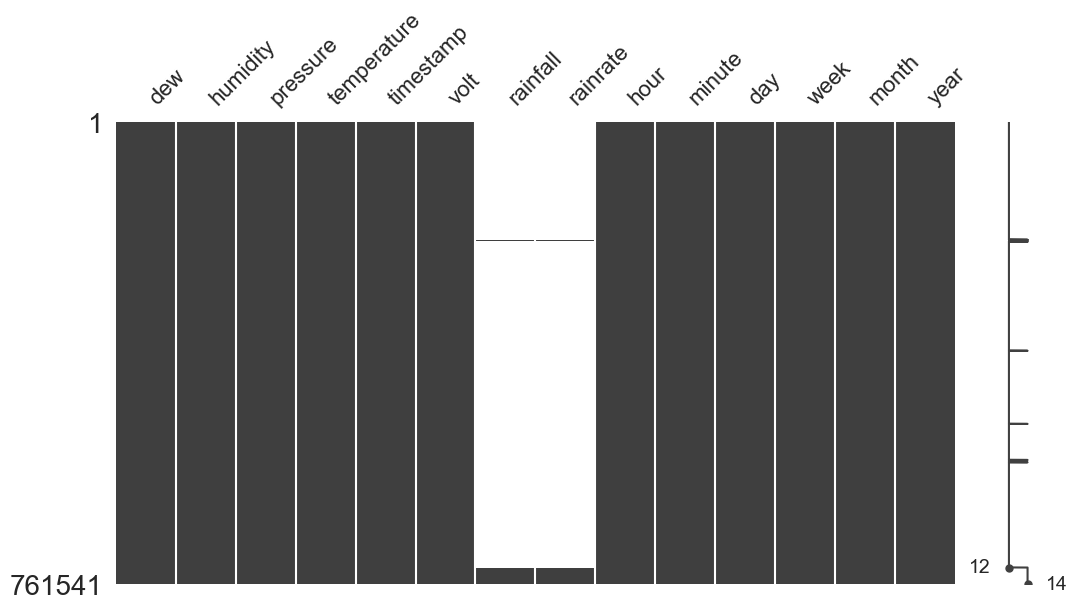


=== Baris dengan Nilai Null ===
Jumlah baris dengan null: 732012

Contoh baris dengan null:
     dew  humidity  pressure  temperature                 timestamp  volt  \
0  24.72     100.0   1010.84        24.72 2025-01-01 00:00:37+07:00  4.07   
1  24.72     100.0   1010.84        24.72 2025-01-01 00:00:41+07:00  4.07   
2  24.73     100.0   1010.79        24.73 2025-01-01 00:01:37+07:00  4.07   
3  24.73     100.0   1010.79        24.73 2025-01-01 00:01:41+07:00  4.07   
4  24.74     100.0   1010.90        24.74 2025-01-01 00:02:37+07:00  4.07   
5  24.74     100.0   1010.90        24.74 2025-01-01 00:02:41+07:00  4.07   
6  24.74     100.0   1010.85        24.74 2025-01-01 00:03:37+07:00  4.07   
7  24.74     100.0   1010.85        24.74 2025-01-01 00:03:41+07:00  4.07   
8  24.73     100.0   1010.86        24.73 2025-01-01 00:04:37+07:00  4.07   
9  24.73     100.0   1010.86        24.73 2025-01-01 00:04:41+07:00  4.07   

   rainfall  rainrate  hour  minute  day  week  month  year

In [15]:
# Mengecek nilai null dalam dataframe cuaca3
print("=== Informasi Missing Values dalam cuaca3 ===\n")
print(cuaca3.isnull().sum())
print("\n" + "="*50 + "\n")

# Menampilkan persentase missing values
print("=== Persentase Missing Values ===\n")
missing_percentage = (cuaca3.isnull().sum() / len(cuaca3)) * 100
print(missing_percentage)
print("\n" + "="*50 + "\n")

# Visualisasi missing values menggunakan missingno
print("=== Visualisasi Missing Values ===")
msno.matrix(cuaca3, figsize=(12, 6))
plt.show()

# Menampilkan baris-baris yang mengandung nilai null
print("\n=== Baris dengan Nilai Null ===")
null_rows = cuaca3[cuaca3.isnull().any(axis=1)]
print(f"Jumlah baris dengan null: {len(null_rows)}")
print("\nContoh baris dengan null:")
print(null_rows.head(10))

=== Informasi Missing Values dalam cuaca5 ===

dew                 0
humidity            0
pressure            0
rainfall           71
rainrate           71
temperature         0
timestamp           0
volt              277
tips           595374
rain_rate      708929
hour                0
minute              0
day                 0
week                0
month               0
year                0
dtype: int64


=== Persentase Missing Values ===

dew             0.000000
humidity        0.000000
pressure        0.000000
rainfall        0.009995
rainrate        0.009995
temperature     0.000000
timestamp       0.000000
volt            0.038994
tips           83.812760
rain_rate      99.798272
hour            0.000000
minute          0.000000
day             0.000000
week            0.000000
month           0.000000
year            0.000000
dtype: float64


=== Visualisasi Missing Values ===


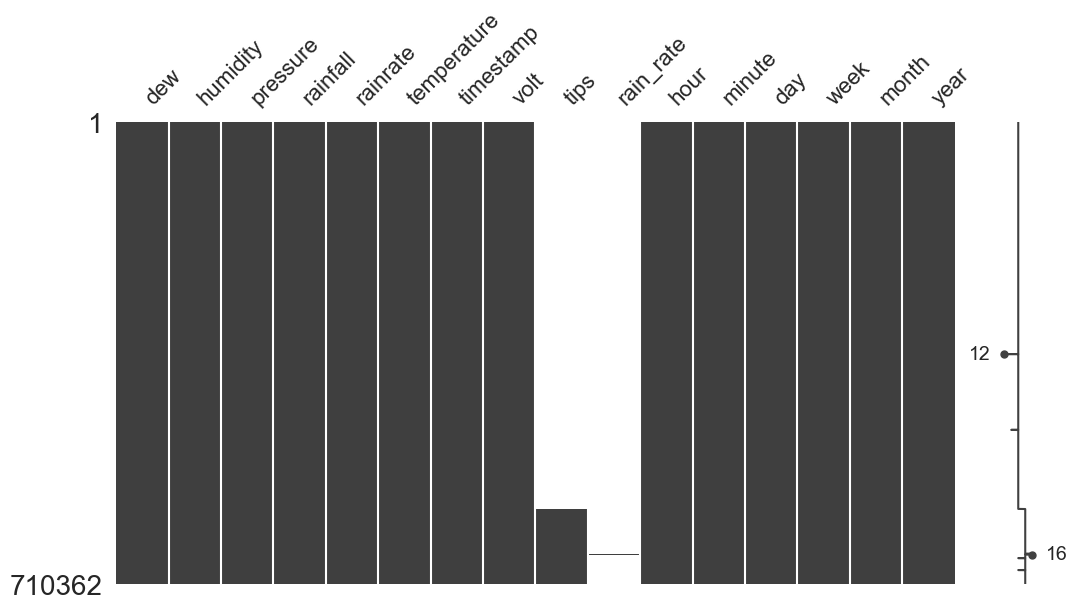


=== Baris dengan Nilai Null ===
Jumlah baris dengan null: 708929

Contoh baris dengan null:
        dew  humidity  pressure  rainfall  rainrate  temperature  \
0  27.74858  97.23300  1011.023   11.7348       0.0     28.23109   
1  27.58560  96.49294  1011.033   11.7348       0.0     28.19905   
2  27.56910  96.34035  1011.045   11.7348       0.0     28.20973   
3  27.68267  96.81529  1011.038   11.7348       0.0     28.23911   
4  27.71058  96.92783  1011.046   11.7348       0.0     28.24712   
5  27.70560  96.80957  1011.059   11.7348       0.0     28.26315   
6  27.63344  96.49294  1011.047   11.7348       0.0     28.24712   
7  27.46198  95.62127  1011.058   11.7348       0.0     28.23109   
8  27.59813  96.20493  1011.048   11.7348       0.0     28.26315   
9  27.58824  96.22400  1011.041   11.7348       0.0     28.24979   

                  timestamp     volt  tips  rain_rate  hour  minute  day  \
0 2025-03-19 13:41:37+07:00  4.20625   NaN        NaN    13      41   19   
1 2025

In [16]:
# Mengecek nilai null dalam dataframe cuaca3
print("=== Informasi Missing Values dalam cuaca5 ===\n")
print(cuaca5.isnull().sum())
print("\n" + "="*50 + "\n")

# Menampilkan persentase missing values
print("=== Persentase Missing Values ===\n")
missing_percentage = (cuaca5.isnull().sum() / len(cuaca5)) * 100
print(missing_percentage)
print("\n" + "="*50 + "\n")

# Visualisasi missing values menggunakan missingno
print("=== Visualisasi Missing Values ===")
msno.matrix(cuaca5, figsize=(12, 6))
plt.show()

# Menampilkan baris-baris yang mengandung nilai null
print("\n=== Baris dengan Nilai Null ===")
null_rows = cuaca5[cuaca5.isnull().any(axis=1)]
print(f"Jumlah baris dengan null: {len(null_rows)}")
print("\nContoh baris dengan null:")
print(null_rows.head(10))

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_station_trends(data_dict, column_to_plot, freq='d', agg_method='mean'):
    """
    Membuat plot tren perbandingan dengan metode agregasi dinamis.

    Args:
        data_dict (dict): Dictionary {station_id: DataFrame}.
        column_to_plot (str): Nama kolom (misal: 'temperature', 'rain_mm').
        freq (str): 'd' (Harian), 'h' (Jam), 'min' (Menit).
        agg_method (str): Metode statistik ('mean', 'median', 'max', 'min', 'sum').
                          Default adalah 'mean'.
    """
    
    # 1. Konfigurasi Label Frekuensi
    freq_config = {
        'd': {'label': 'Harian', 'xlabel': 'Tanggal', 'code': 'd'}, # code: alias pandas
        'h': {'label': 'Per Jam', 'xlabel': 'Waktu (Jam)', 'code': 'h'},
        'min': {'label': 'Per Menit', 'xlabel': 'Waktu (Menit)', 'code': 'min'}
    }
    
    # Ambil config, default ke Harian jika typo
    selected_freq = freq_config.get(freq, freq_config['d'])
    
    # 2. Konfigurasi Label Agregasi (Biar judul grafik bahasa Indonesia)
    agg_labels = {
        'mean': 'Rata-rata',
        'median': 'Median (Nilai Tengah)',
        'max': 'Maksimum (Tertinggi)',
        'min': 'Minimum (Terendah)',
        'sum': 'Total Akumulasi'
    }
    # Ambil label indo, kalau gak ada pakai teks aslinya (misal 'std')
    agg_display_name = agg_labels.get(agg_method, agg_method.capitalize())

    # Mulai Plotting
    plt.figure(figsize=(15, 7))

    # Loop stasiun
    for station_id, df in data_dict.items():
        if column_to_plot not in df.columns:
            print(f"⚠️ Peringatan: Kolom '{column_to_plot}' tidak ada di {station_id}. Skip.")
            continue

        temp_df = df.copy()
        
        # Pastikan timestamp adalah datetime
        if not pd.api.types.is_datetime64_any_dtype(temp_df['timestamp']):
             temp_df['timestamp'] = pd.to_datetime(temp_df['timestamp'])

        # 3. PROSES GROUPING & AGREGASI DINAMIS
        # Kita buat kolom bantuan untuk grouping waktu
        time_col = f'time_group_{freq}'
        
        # dt.floor membulatkan waktu ke bawah (misal 13:45 -> 13:00 untuk jam)
        temp_df[time_col] = temp_df['timestamp'].dt.floor(selected_freq['code'])
        
        # INI BAGIAN KUNCI: .agg(agg_method) menggantikan .mean()
        # agg_method bisa berisi string: 'mean', 'sum', 'max', dll.
        trend_data = temp_df.groupby(time_col)[column_to_plot].agg(agg_method).reset_index()

        # Plotting
        plt.plot(trend_data[time_col], trend_data[column_to_plot], label=station_id, alpha=0.8)

    # 4. Mempercantik Visualisasi
    plt.xlabel(selected_freq['xlabel'], fontsize=12)
    plt.ylabel(f"{agg_display_name} {column_to_plot.replace('_', ' ').capitalize()}", fontsize=12)
    
    plt.title(f"Perbandingan {agg_display_name} {column_to_plot} ({selected_freq['label']})", 
              fontsize=14, fontweight='bold')
    
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()

    plt.show()

Menampilkan plot perbandingan per jam...


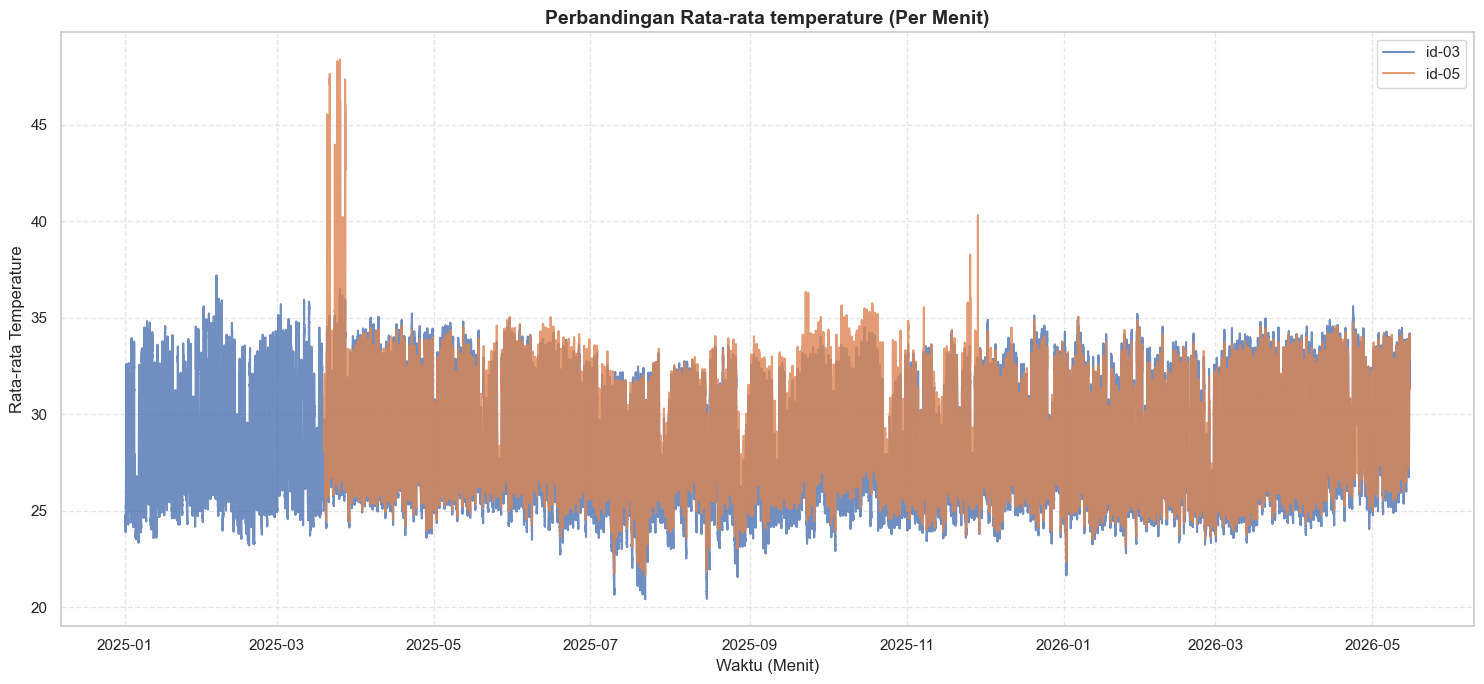

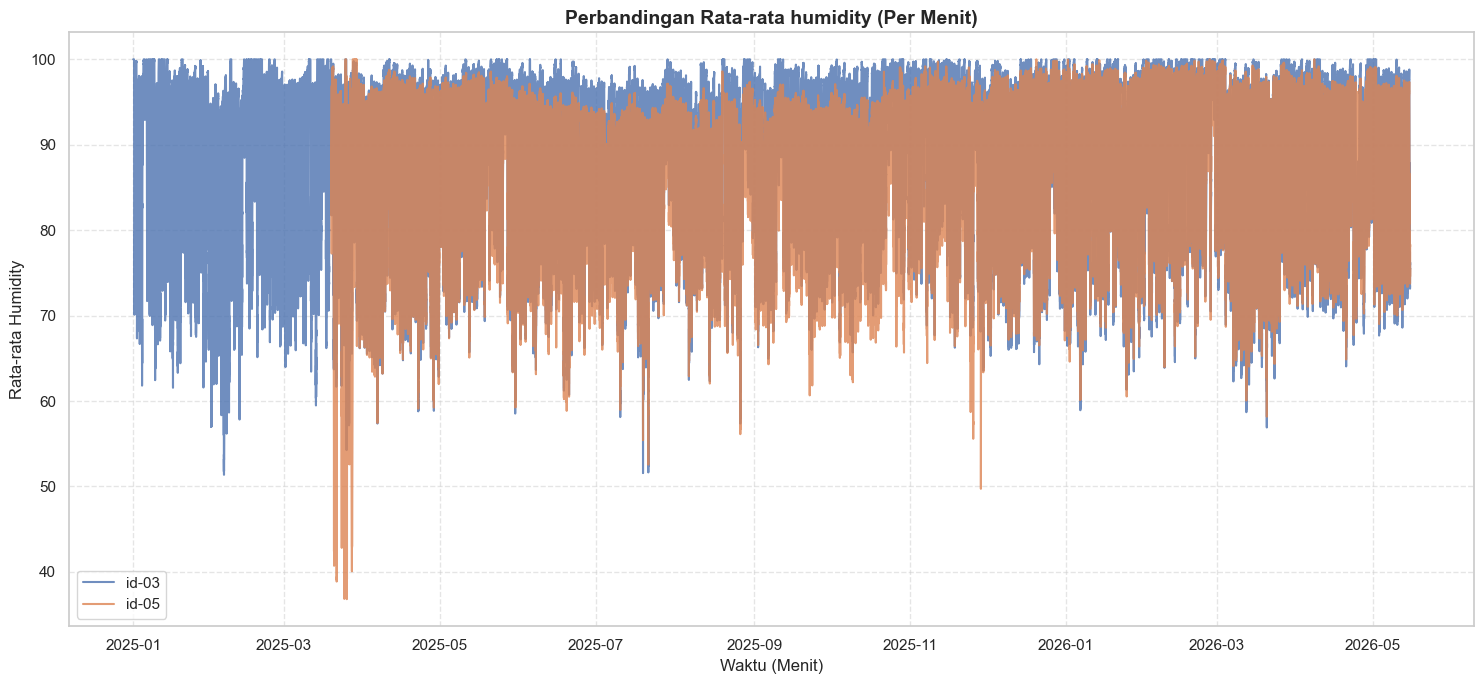

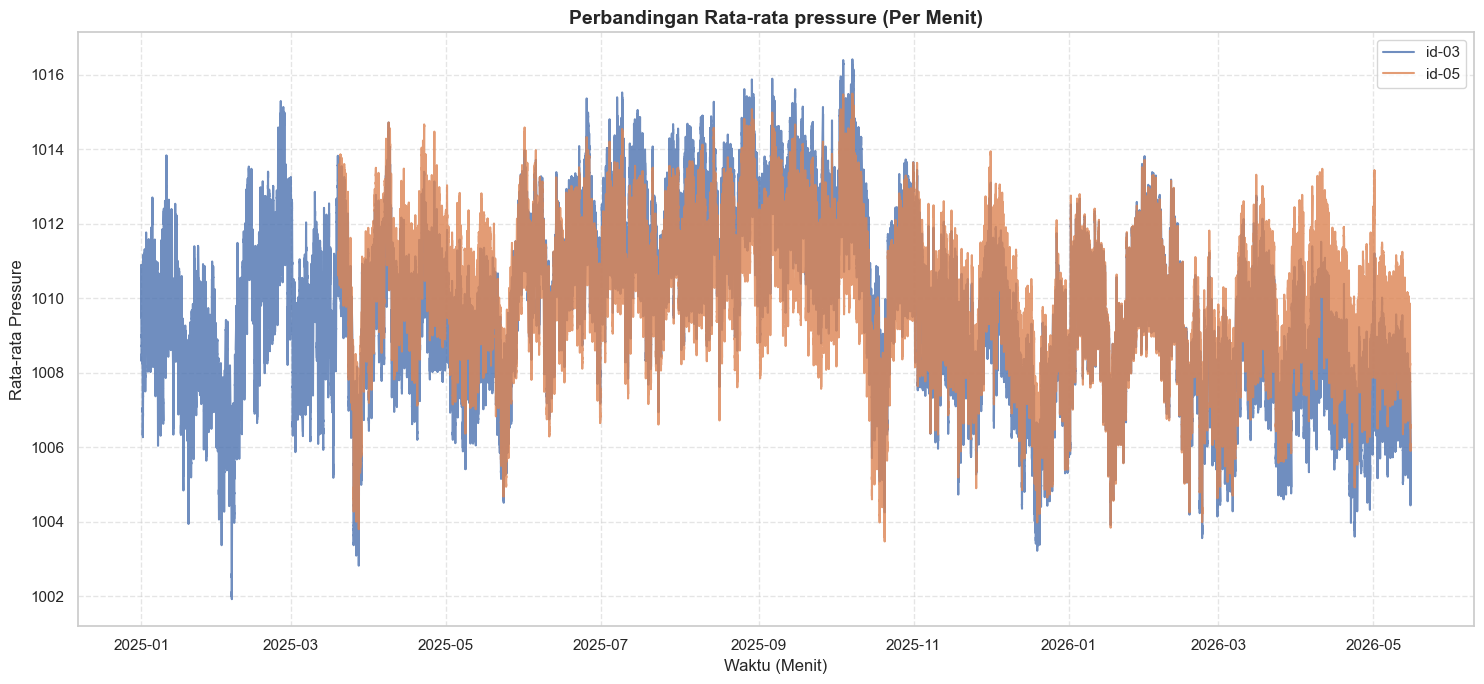

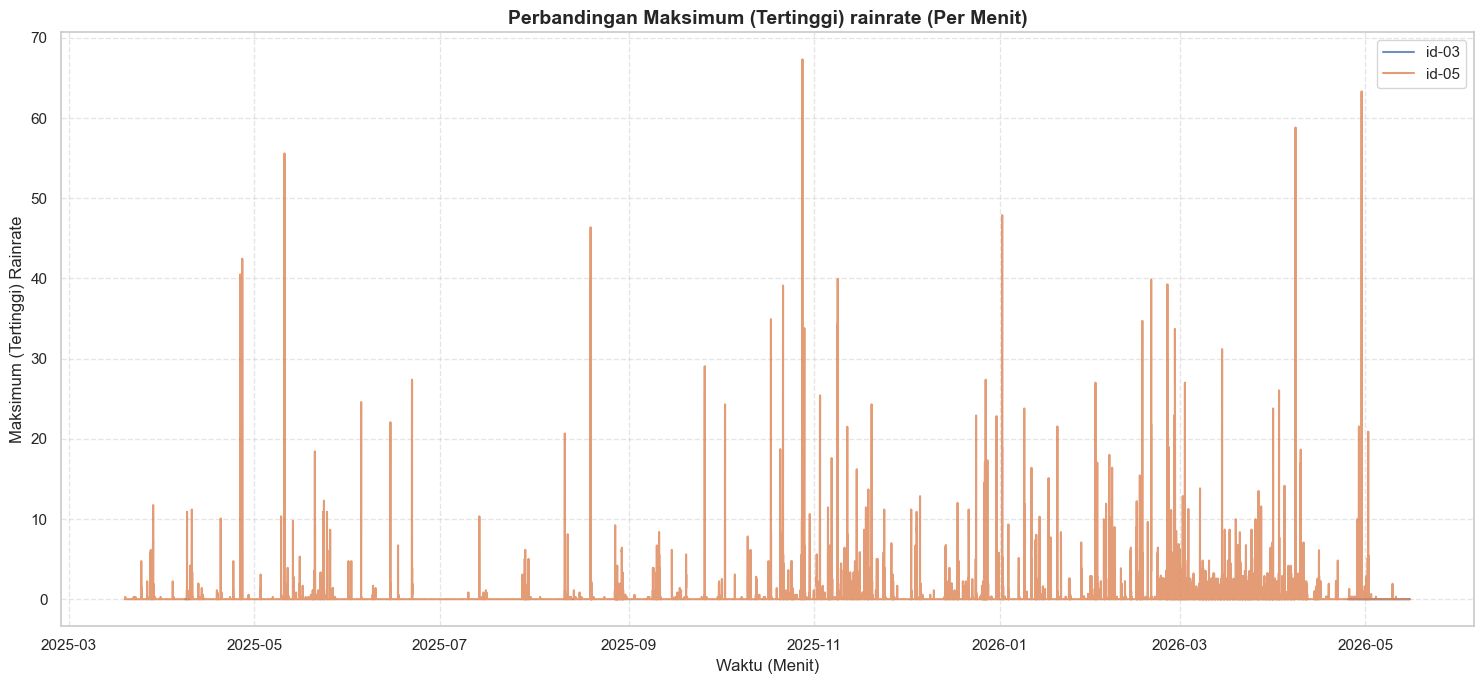

In [18]:
# --- 1. Membuat Plot Rata-rata PER JAM ---
# Cukup atur freq='h'
print("Menampilkan plot perbandingan per jam...")
plot_station_trends(weather_dataframes, 'temperature', freq='min', agg_method='mean')
plot_station_trends(weather_dataframes, 'humidity', freq='min', agg_method='mean')
plot_station_trends(weather_dataframes, 'pressure', freq='min', agg_method='mean')
plot_station_trends(weather_dataframes, 'rainrate', freq='min', agg_method='max')


Menampilkan plot perbandingan per hari...


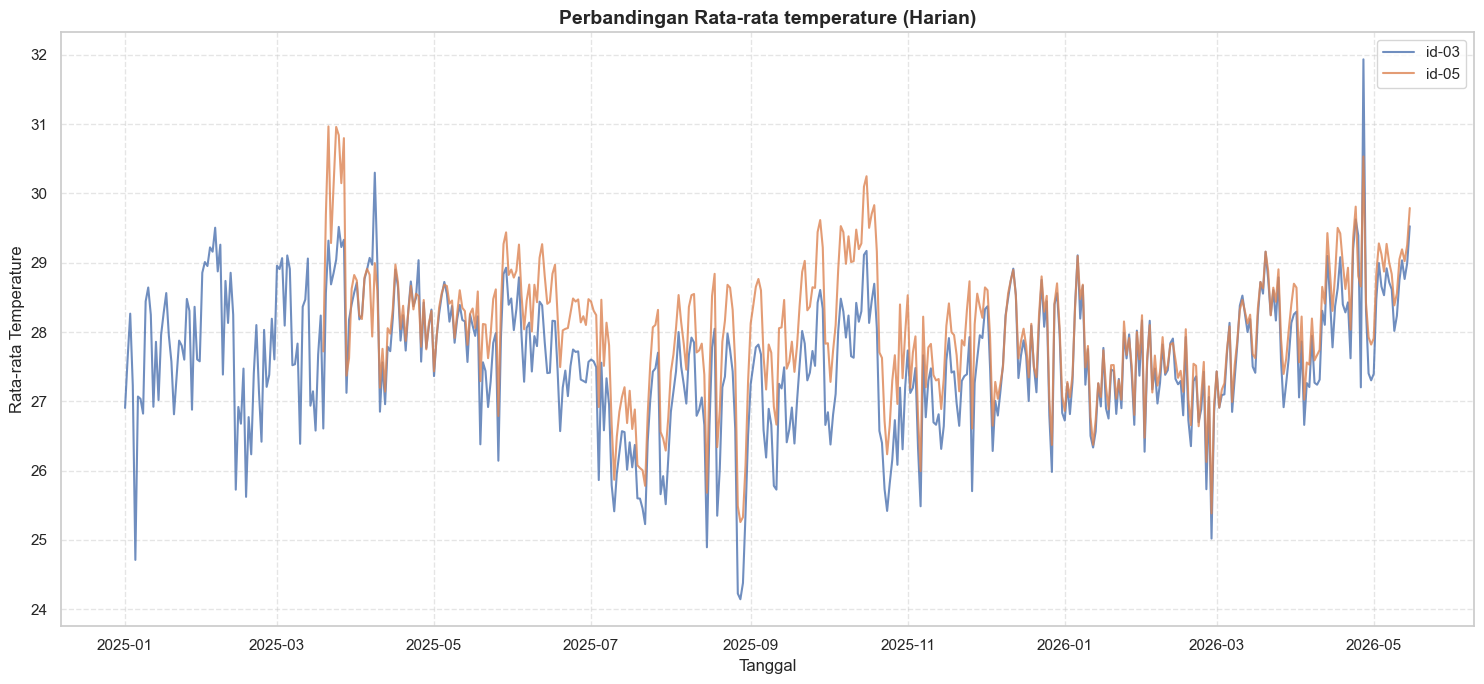

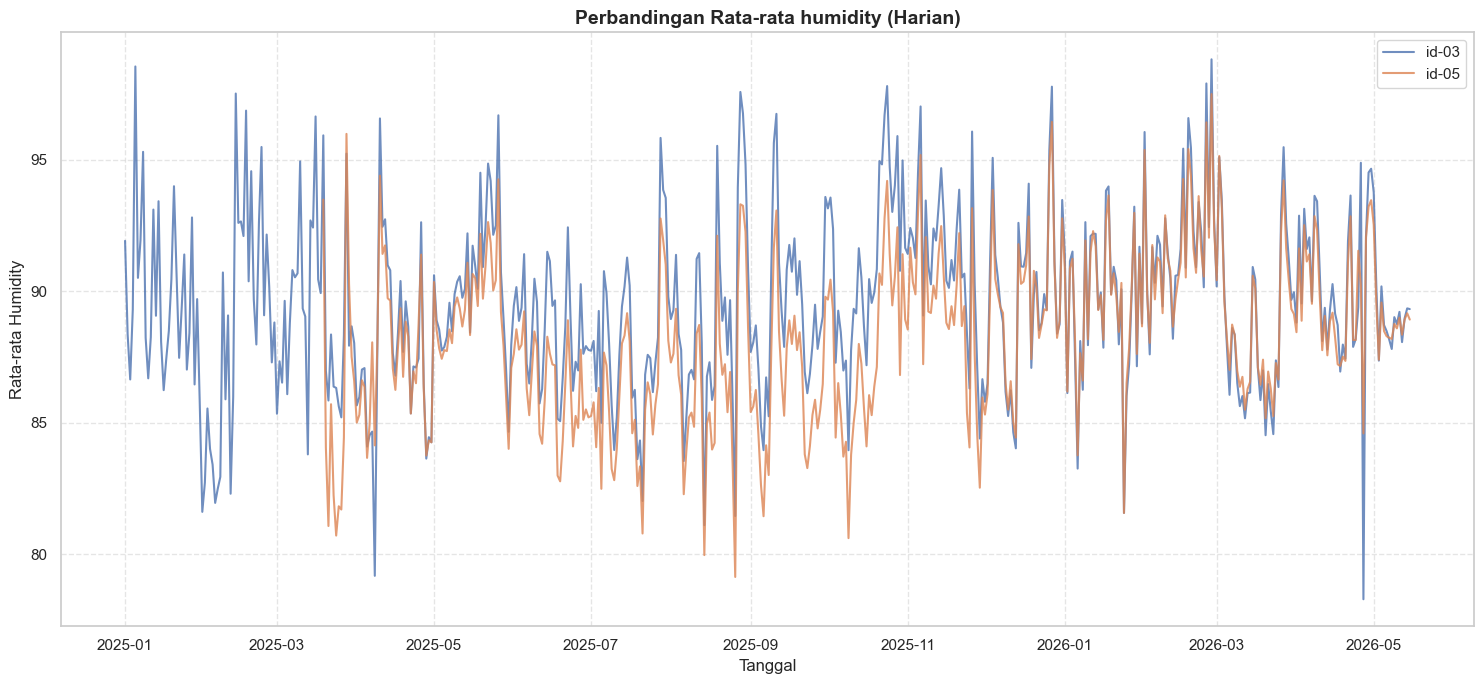

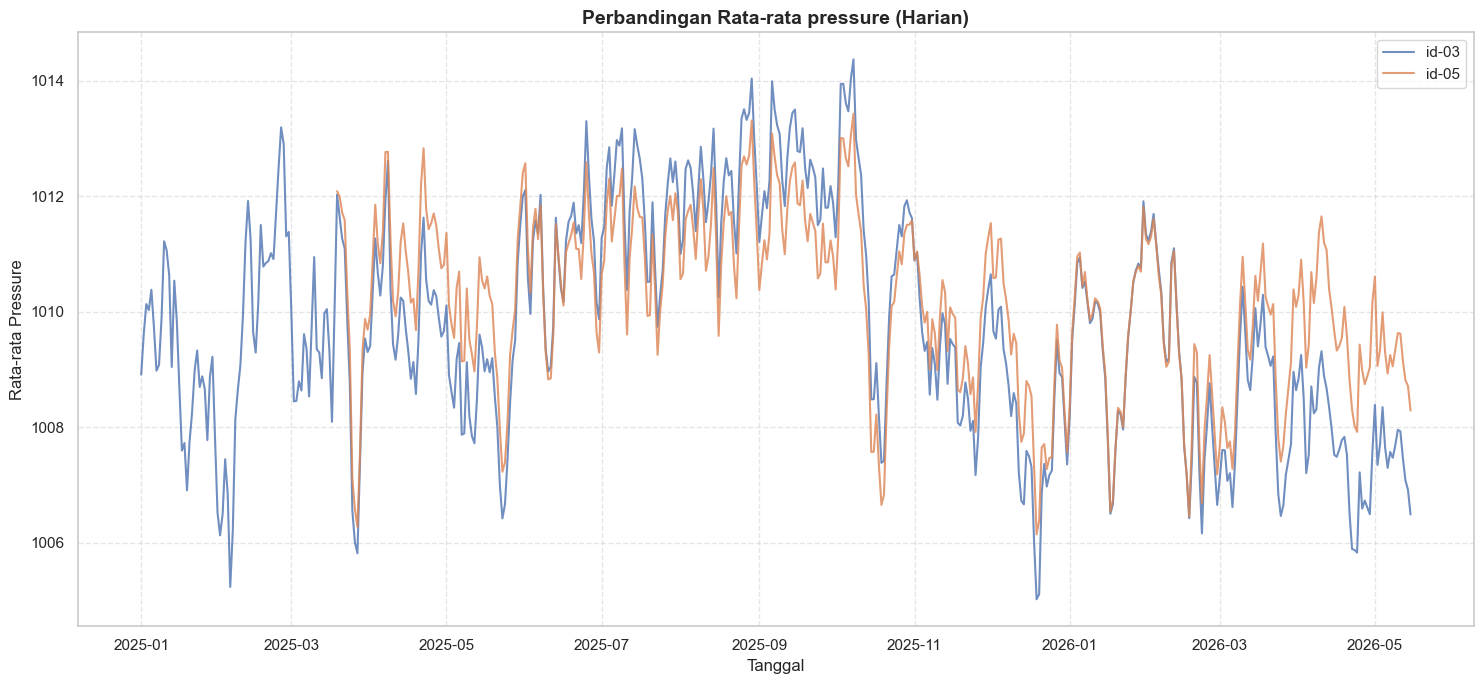

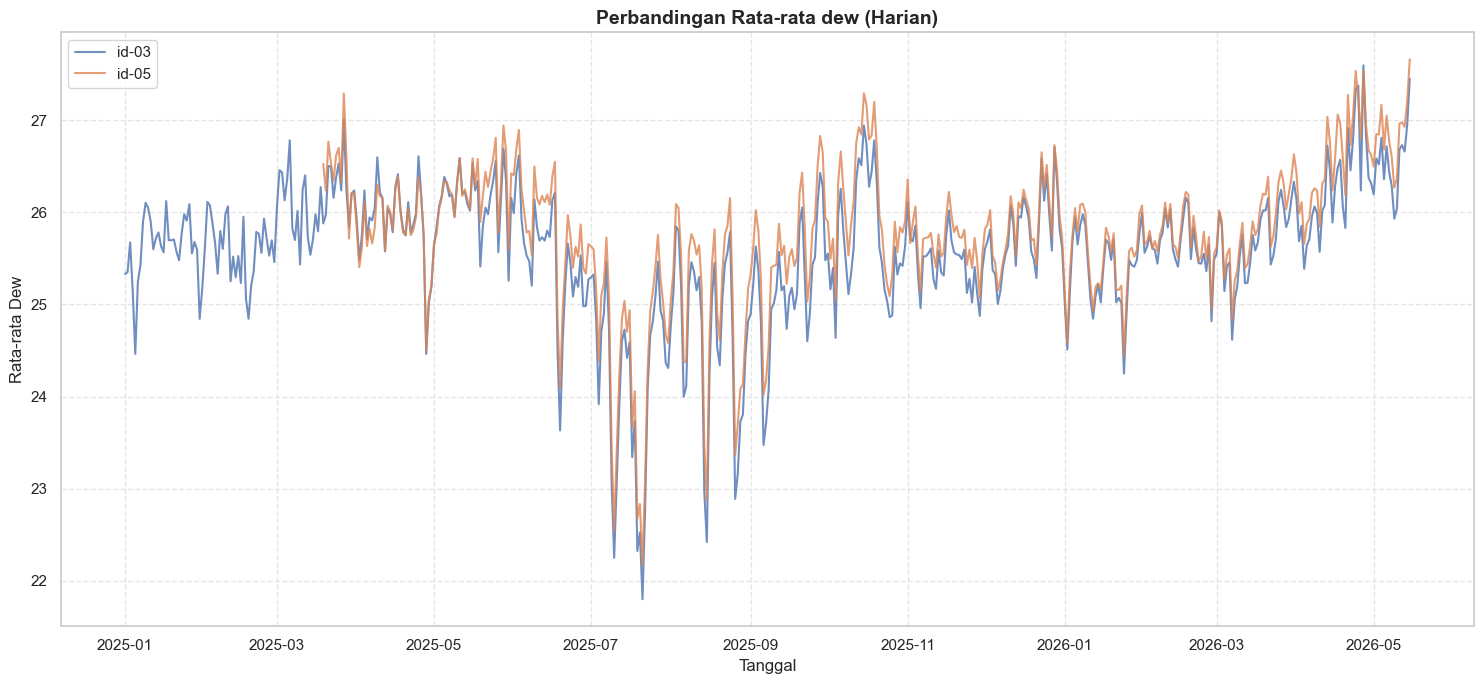

In [19]:
# --- 2. Membuat Plot Rata-rata PER HARI ---
# Gunakan nilai default freq='d' atau tulis secara eksplisit
print("\nMenampilkan plot perbandingan per hari...")
plot_station_trends(weather_dataframes, 'temperature', freq='d', agg_method='mean')
plot_station_trends(weather_dataframes, 'humidity', freq='d', agg_method='mean')
plot_station_trends(weather_dataframes, 'pressure', freq='d', agg_method='mean')
plot_station_trends(weather_dataframes, 'dew', freq='d', agg_method='mean')

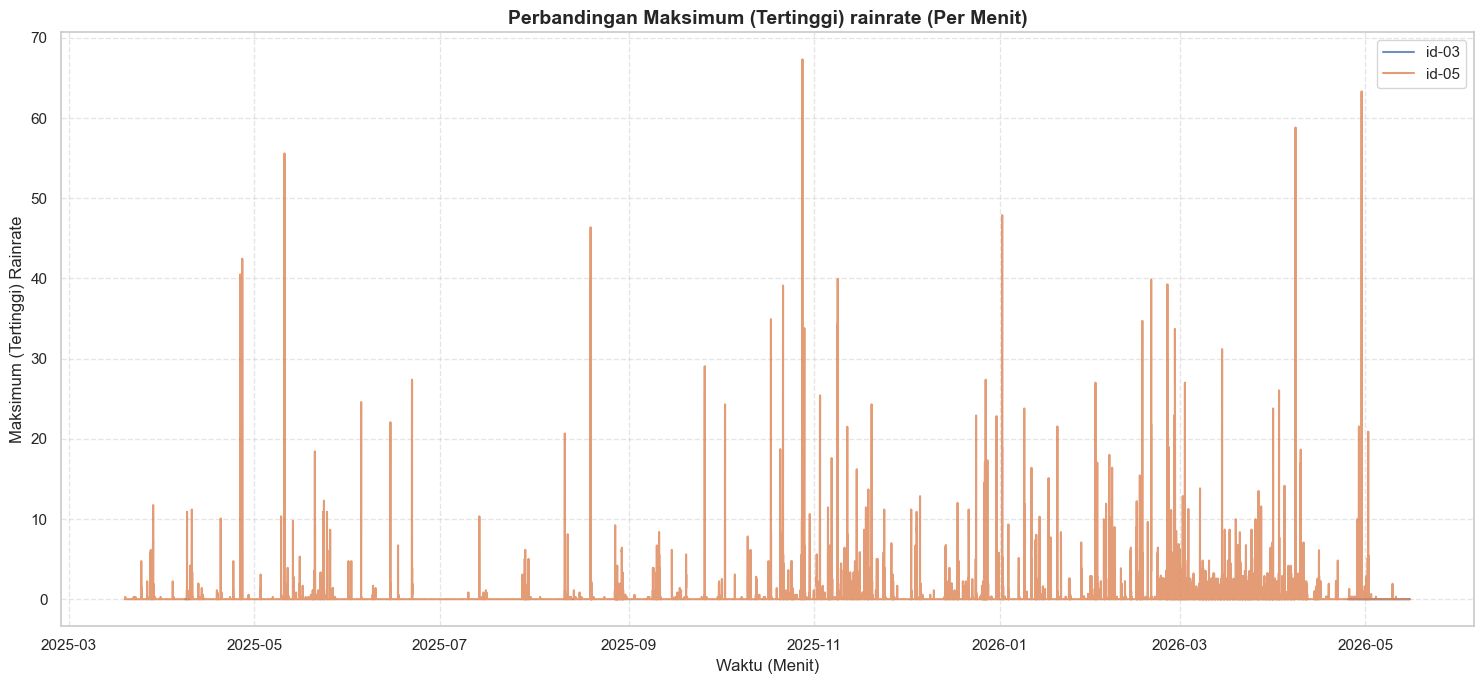

In [20]:
plot_station_trends(weather_dataframes, 'rainrate', freq='min', agg_method='max')

In [21]:
import pandas as pd
import numpy as np

# =======================================================
# 1. PERSIAPAN DATA WAKTU
# =======================================================
# Pastikan kolom waktu sudah format datetime dan jadi index
cuaca5['timestamp'] = pd.to_datetime(cuaca5['timestamp'])
cuaca5 = cuaca5.sort_values('timestamp').set_index('timestamp')

# =======================================================
# 2. DETEKSI INCREMENT (SELISIH) & PENANGANAN RESET
# =======================================================
# Hitung selisih dari baris sebelumnya
cuaca5['delta_raw'] = cuaca5['rainrate'].diff()

# LOGIKA RESET: 
# Jika delta_raw negatif, artinya terjadi RESET (baik normal pergantian jam atau abnormal karena alat mati).
# Jika reset terjadi, nilai hujan aktual yang baru saja turun adalah nilai 'rainrate' itu sendiri.
# Jika delta_raw positif, itu adalah penambahan hujan biasa.
cuaca5['actual_increment'] = np.where(
    cuaca5['delta_raw'] < 0, 
    cuaca5['rainrate'],      # Ambil angka setelah reset
    cuaca5['delta_raw']      # Ambil selisih normal
)

# Bersihkan NaN di baris pertama atau angka aneh
cuaca5['actual_increment'] = cuaca5['actual_increment'].fillna(0).clip(lower=0)

# =======================================================
# 3. PEMBULATAN TIP (STANDARISASI KE 0.3)
# =======================================================
# Karena alat kadang mencatat 0.2794 atau 0.3215, kita paksa semuanya jadi kelipatan 0.3
# Caranya: cari tahu itu berapa kali "tip" (ketukan), lalu kalikan 0.3
cuaca5['tips_count'] = np.round(cuaca5['actual_increment'] / 0.3)
cuaca5['increment_fixed'] = cuaca5['tips_count'] * 0.3

# =======================================================
# 4. REKONSTRUKSI RAINRATE PER JAM
# =======================================================
# Kita susun ulang rainrate yang benar dengan menjumlahkan increment_fixed 
# secara kumulatif, dan kita paksa reset HANYA di awal jam (Normal Reset)
cuaca5['rainrate_fixed'] = cuaca5.groupby(cuaca5.index.floor('H'))['increment_fixed'].cumsum()

# =======================================================
# 5. AGREGASI HARIAN (SESUAI PERMINTAAN)
# =======================================================
df_hourly = cuaca5.resample('H').agg({
    'rainrate': 'max',  # Mengambil total akumulasi tertinggi di jam tersebut
    'temperature': 'mean',    # Rata-rata suhu
    'humidity': 'mean',       # Rata-rata kelembapan
    'pressure': 'mean',       # Rata-rata tekanan
    'dew': 'mean'             # Rata-rata titik embun
})

# Ubah nama kolom agar rapi kembali
df_hourly = df_hourly.rename(columns={'rainrate_fixed': 'rain_mm'})

# Tampilkan hasil
print("✅ Pemrosesan Selesai. Data Agregasi Per Jam:")
print(df_hourly.head(10))

C:\Users\acer\AppData\Local\Temp\ipykernel_5872\1399442594.py:43: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  cuaca5['rainrate_fixed'] = cuaca5.groupby(cuaca5.index.floor('H'))['increment_fixed'].cumsum()
C:\Users\acer\AppData\Local\Temp\ipykernel_5872\1399442594.py:48: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = cuaca5.resample('H').agg({


✅ Pemrosesan Selesai. Data Agregasi Per Jam:
                           rainrate  temperature   humidity     pressure  \
timestamp                                                                  
2025-03-19 13:00:00+07:00    0.0000    28.163365  94.335827  1011.120959   
2025-03-19 14:00:00+07:00    0.2794    29.084335  91.649419  1010.880125   
2025-03-19 15:00:00+07:00    0.2794    30.934129  83.867371  1010.835198   
2025-03-19 16:00:00+07:00    0.0000    30.897955  83.783592  1010.911521   
2025-03-19 17:00:00+07:00    0.0000    28.565734  90.632079  1011.434678   
2025-03-19 18:00:00+07:00    0.0000    27.037647  94.918693  1011.847287   
2025-03-19 19:00:00+07:00    0.0000    26.603566  96.829447  1012.464685   
2025-03-19 20:00:00+07:00    0.0000    26.311772  97.622218  1013.006779   
2025-03-19 21:00:00+07:00    0.0000    26.173208  98.185907  1013.179163   
2025-03-19 22:00:00+07:00    0.0000    25.865855  98.240673  1013.466967   

                                 dew  
tim

C:\Users\acer\AppData\Local\Temp\ipykernel_5872\2650539322.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


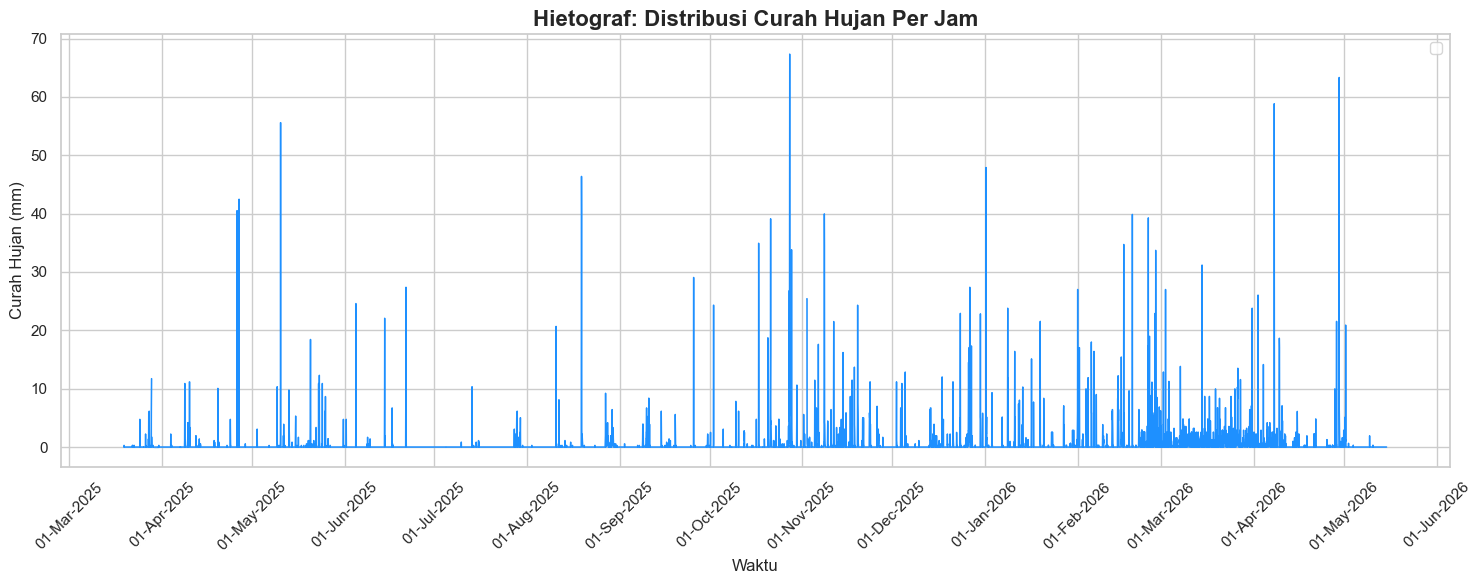

In [23]:
# Set Style biar ganteng
sns.set(style="whitegrid")

plt.figure(figsize=(15, 6))

# A. PLOT DATA
# Kita pakai bar plot, tapi karena indexnya datetime, kita atur width-nya
# Width 0.03 hari (sekitar 45 menit) biar ada celah dikit antar jam
#plt.bar(df_hourly.index, df_hourly['rain_mm'], color='dodgerblue', width=1, label='Curah Hujan (mm/jam)')

# Alternatif kalau data sangat padat (tahunan), pakai ini:
plt.plot(df_hourly.index, df_hourly['rainrate'], color='dodgerblue', lw=1)
plt.fill_between(df_hourly.index, df_hourly['rainrate'], color='dodgerblue', alpha=0.3)

# B. PERCANTIK
plt.title('Hietograf: Distribusi Curah Hujan Per Jam', fontsize=16, fontweight='bold')
plt.ylabel('Curah Hujan (mm)', fontsize=12)
plt.xlabel('Waktu', fontsize=12)
plt.legend(loc='upper right')

# Format Tanggal di Sumbu X biar rapi
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b-%Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) # Label per bulan
plt.xticks(rotation=45)

# Batas Y (opsional, biar kelihatan ruang atasnya)
# plt.ylim(0, df_hourly['rain_mm'].max() * 1.2) 

plt.tight_layout()
plt.show()

In [24]:
# ==============================================================================
# 1. KONFIGURASI
# ==============================================================================
PATH_FILE_DESA = 'D:\Github\Catatan_Meteorologi\Analisis_Meteorologi\open_meteo_jerukagung\cuaca_jerukagung.csv'

In [25]:
def load_data(filepath):
    if not os.path.exists(filepath):
        print(f"❌ File tidak ditemukan: {filepath}")
        return None
    try:
        df = pd.read_csv(filepath, index_col='date')
        df.index = pd.to_datetime(df.index, utc=True, errors='coerce')
        df.index = df.index.tz_convert('Asia/Jakarta')
        df.index = df.index.tz_localize(None)
        df = df.sort_index()
        return df
    except Exception as e:
        print(f"❌ Error: {e}")
        return None

In [ ]:
# 1. Load semua data dulu
df_era5 = load_data(PATH_FILE_DESA)

# ==============================================================================
# 🛠️ TAHAP 1: PERSIAPAN SLICING (Jadikan Naive Sementara)
# ==============================================================================
# Kita ubah dulu ke waktu Jakarta, lalu "copot" labelnya sementara.
# Tujuannya: Agar sintaks slicing .loc['2025'] berjalan mulus tanpa error.

if df_era5.index.tz is not None:
    # 1. Pastikan jamnya sudah digeser ke WIB (+07:00)
    df_era5.index = df_era5.index.tz_convert('Asia/Jakarta')
    
    # 2. HAPUS label zona waktunya sementara
    # Jam 07:00 WIB (+7) akan menjadi jam 07:00 (Polos)
    df_era5.index = df_era5.index.tz_localize(None)

print("Index sementara dikonversi ke Naive (untuk filtering).")

# ==============================================================================
# 🛠️ TAHAP 2: FILTERING & RE-LOCALIZATION (Pasang Lagi Zonanya)
# ==============================================================================

# 1. Ambil data tahun 2025
df_era5 = df_era5.loc['2025':'2026'].copy()

# 2. PASANG KEMBALI ZONA WAKTU ASIA/JAKARTA 
# Karena tadi kita sudah pastikan jamnya benar (langkah Tahap 1.1),
# kita tinggal tempel label 'Asia/Jakarta' lagi.
df_era5.index = df_era5.index.tz_localize('Asia/Jakarta')

print("\n" + "="*40)
print("FILTER BERHASIL & ZONA WAKTU TERPASANG")
print("="*40)
print(f"Zona Waktu: {df_era5.index.tz}") # Harus muncul Asia/Jakarta
print(f"Start     : {df_era5.index.min()}")
print(f"End       : {df_era5.index.max()}")
print(f"Total     : {len(df_era5)} baris")
df_era5.info()

Index sementara dikonversi ke Naive (untuk filtering).

FILTER BERHASIL & ZONA WAKTU TERPASANG
Zona Waktu: Asia/Jakarta
Start     : 2025-01-01 00:00:00+07:00
End       : 2026-05-13 23:00:00+07:00
Total     : 11952 baris
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11952 entries, 2025-01-01 00:00:00+07:00 to 2026-05-13 23:00:00+07:00
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   temperature        11839 non-null  float64
 1   humidity           11839 non-null  float64
 2   dewpoint           11839 non-null  float64
 3   rain_mm            11839 non-null  float64
 4   wind_speed         11839 non-null  float64
 5   wind_gusts         11839 non-null  float64
 6   wind_direction     11839 non-null  float64
 7   pressure           11839 non-null  float64
 8   sealevel_pressure  11839 non-null  float64
 9   sunshine_duration  11839 non-null  float64
 10  direct_radiation   11839 non-null  float64


In [ ]:
df_hourly.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10130 entries, 2025-03-19 13:00:00+07:00 to 2026-05-15 14:00:00+07:00
Freq: h
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rainrate     10091 non-null  float64
 1   temperature  10092 non-null  float64
 2   humidity     10092 non-null  float64
 3   pressure     10092 non-null  float64
 4   dew          10092 non-null  float64
dtypes: float64(5)
memory usage: 474.8 KB



📊 ANALISIS PERBANDINGAN: CURAH HUJAN
1. Statistik Error:
   - MAE  : 0.80 mm/jam
   - RMSE : 3.02 mm/jam
   - Bias Max (Model - Sensor): 18.54 mm/jam
   - Bias Min (Model - Sensor): -67.24 mm/jam
   - Bias (Rata-rata Selisih): -0.19 mm/jam

2. Statistik Hubungan:
   - Pearson (Linear)    : 0.1057
   - Spearman (Ranking)  : 0.1907


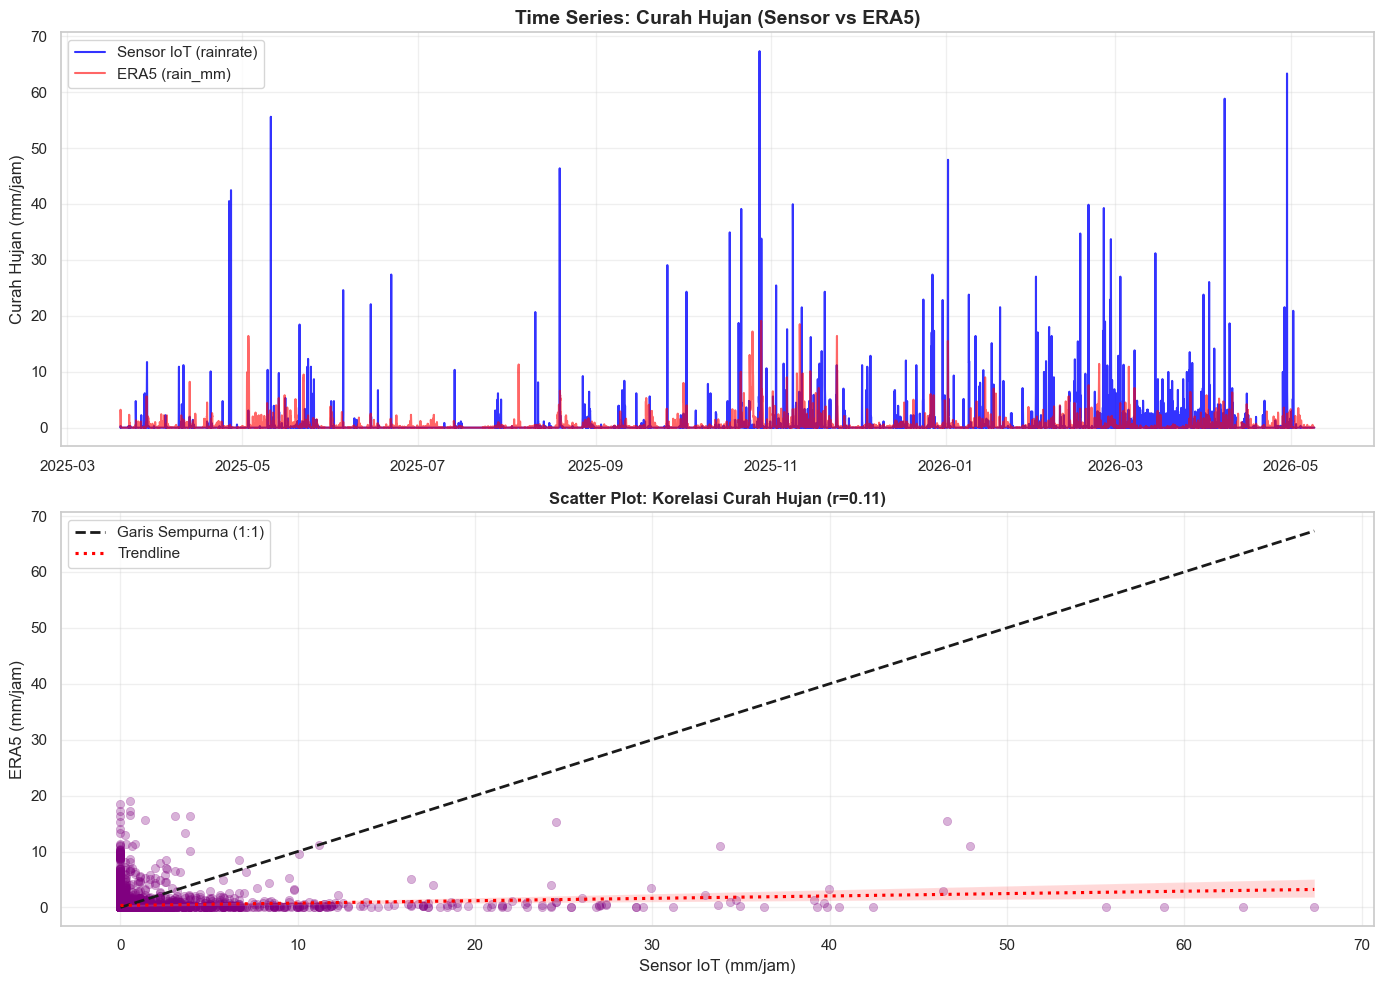


📊 ANALISIS PERBANDINGAN: SUHU UDARA
1. Statistik Error:
   - MAE  : 1.33 °C
   - RMSE : 1.76 °C
   - Bias Max (Model - Sensor): 4.82 °C
   - Bias Min (Model - Sensor): -14.50 °C
   - Bias (Rata-rata Selisih): -1.02 °C

2. Statistik Hubungan:
   - Pearson (Linear)    : 0.8555
   - Spearman (Ranking)  : 0.8476


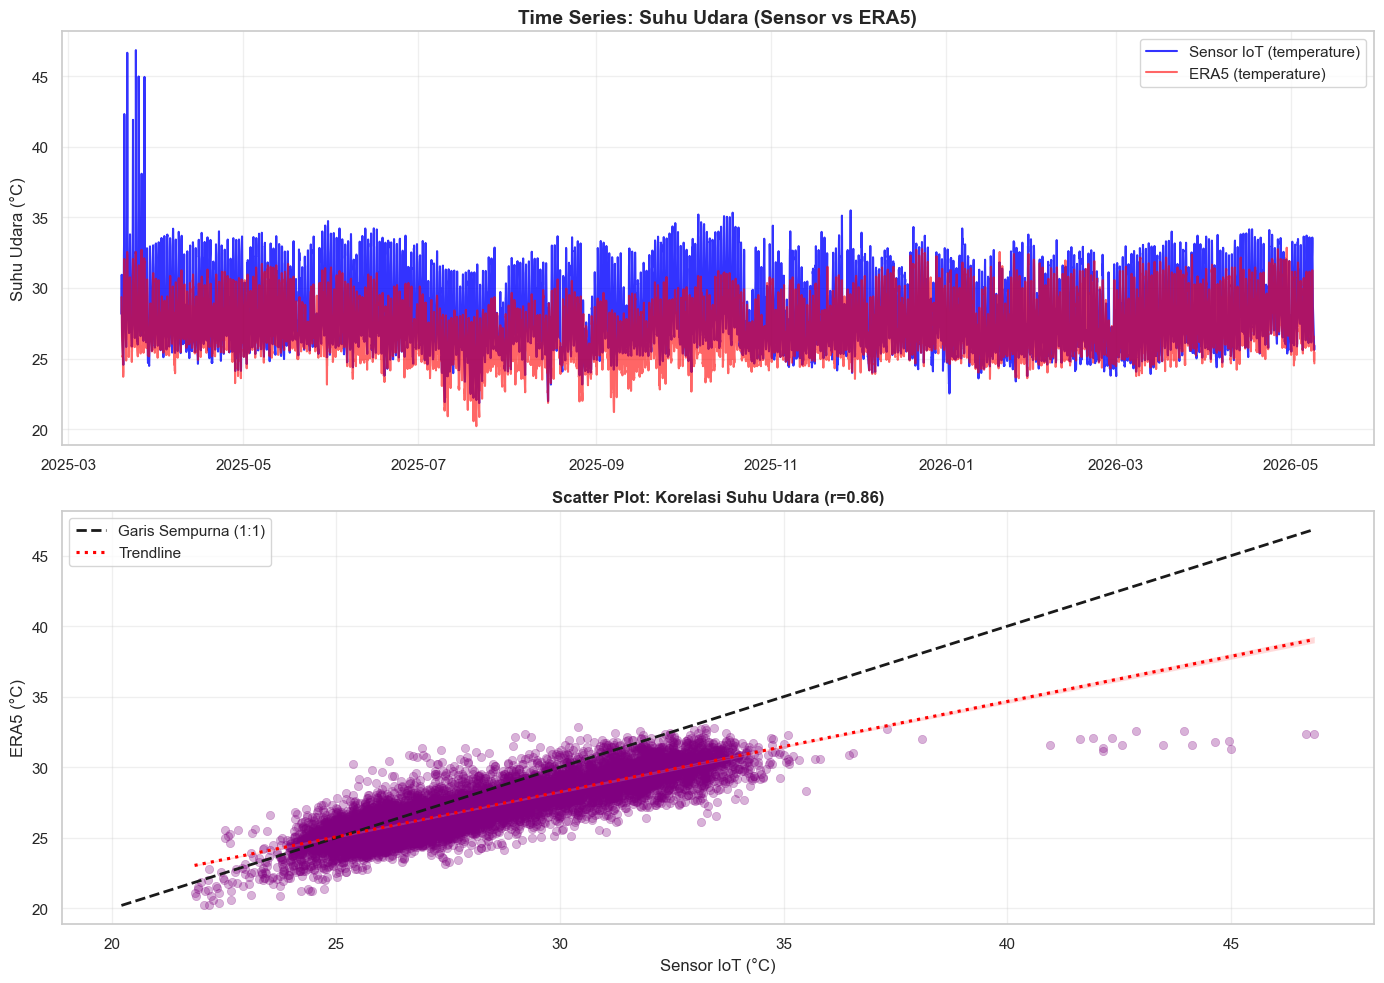


📊 ANALISIS PERBANDINGAN: KELEMBAPAN
📅 Periode: 2025-04-01 s.d Akhir
1. Statistik Error:
   - MAE  : 4.91 %
   - RMSE : 6.24 %
   - Bias Max (Model - Sensor): 15.87 %
   - Bias Min (Model - Sensor): -30.24 %
   - Bias (Rata-rata Selisih): -3.32 %

2. Statistik Hubungan:
   - Pearson (Linear)    : 0.8093
   - Spearman (Ranking)  : 0.7564


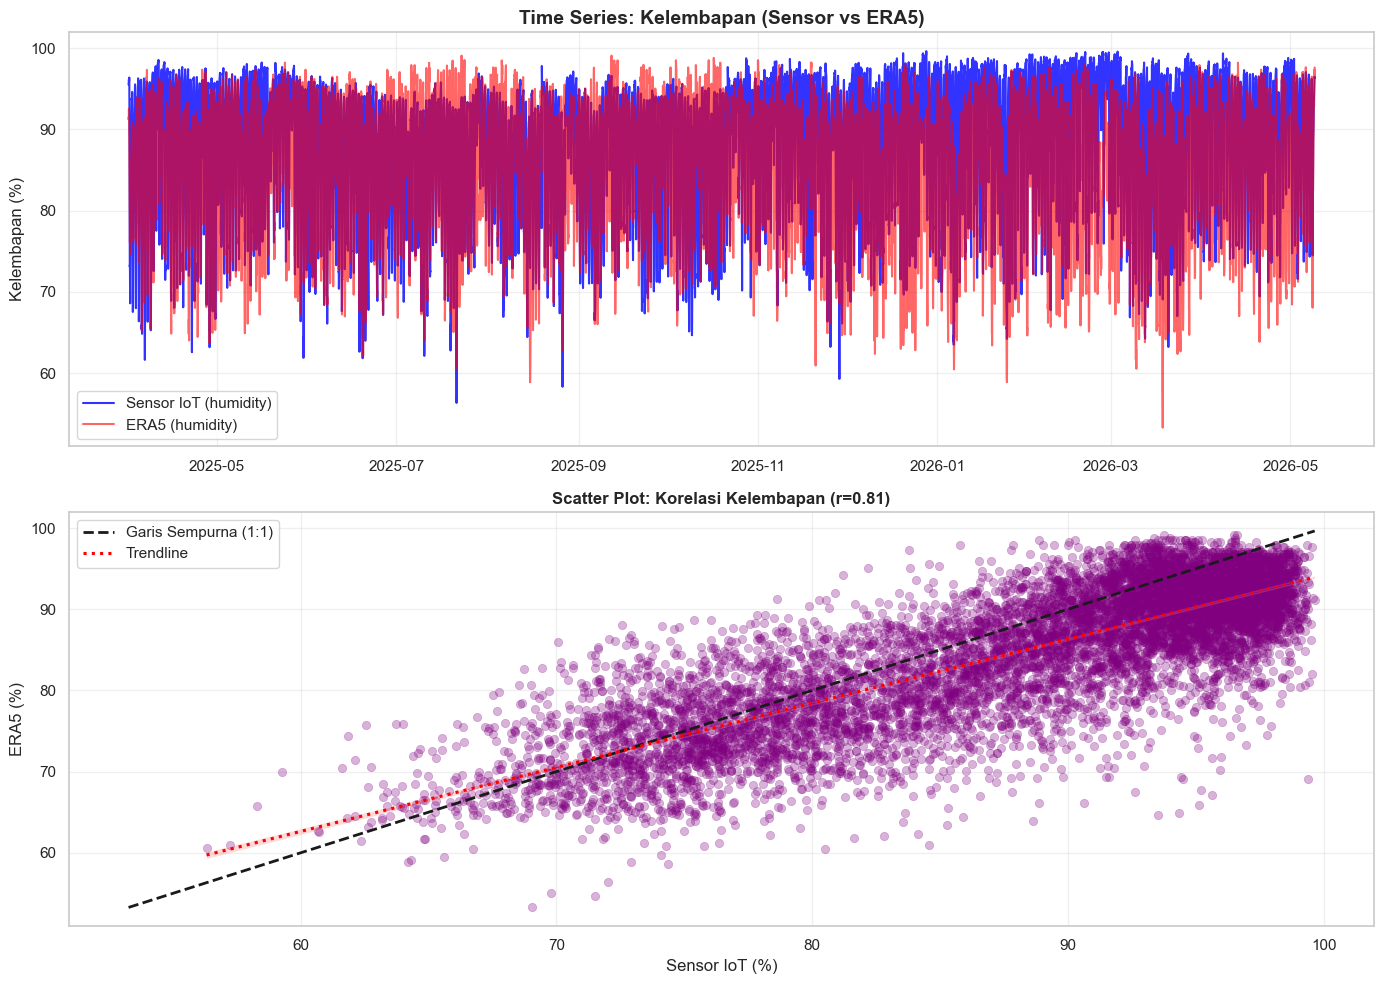

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error

def bandingkan_variabel(target_sensor, target_meteo, nama_variabel, satuan, start_time=None, end_time=None):
    """
    Fungsi untuk membandingkan data Sensor vs Open-Meteo/ERA5 dengan filter waktu (opsional)
    Format start_time & end_time: 'YYYY-MM-DD' atau 'YYYY-MM-DD HH:MM:SS'
    """
    print(f"\n" + "="*60)
    print(f"📊 ANALISIS PERBANDINGAN: {nama_variabel.upper()}")
    if start_time or end_time:
        print(f"📅 Periode: {start_time if start_time else 'Awal'} s.d {end_time if end_time else 'Akhir'}")
    print("="*60)

    # 1. SIAPKAN DATA & PENGECEKAN KOLOM
    if target_sensor not in df_hourly.columns:
        print(f"❌ Error: Kolom sensor '{target_sensor}' tidak ditemukan di df_hourly.")
        return
    if target_meteo not in df_era5.columns:
        print(f"❌ Error: Kolom model '{target_meteo}' tidak ditemukan di df_era5.")
        return

    # --- TRIK ROBUST: Ganti nama kolom sebelum digabung ---
    s_sensor = df_hourly[target_sensor].rename('Nilai_Sensor')
    s_meteo = df_era5[target_meteo].rename('Nilai_Satelit')

    # Gabungkan berdasarkan index waktu yang sama
    df_compare = pd.concat([s_sensor, s_meteo], axis=1)
    
    # --- FILTER WAKTU ---
    if start_time and end_time:
        df_compare = df_compare.loc[start_time:end_time]
    elif start_time:
        df_compare = df_compare.loc[start_time:]
    elif end_time:
        df_compare = df_compare.loc[:end_time]
    
    # Cek apakah data kosong setelah difilter
    if df_compare.empty:
        print("⚠️ Peringatan: Data kosong pada rentang waktu tersebut!")
        return

    # Hapus NaN (hanya pertahankan waktu di mana kedua alat menyala/ada datanya)
    df_compare = df_compare.dropna()
    
    # Ambil Series untuk perhitungan statistik
    x = df_compare['Nilai_Sensor']
    y = df_compare['Nilai_Satelit']

    # 2. HITUNG STATISTIK ERROR
    mae = mean_absolute_error(x, y)
    rmse = np.sqrt(mean_squared_error(x, y))
    bias_max = (y - x).max()
    bias_min = (y - x).min()
    bias = (y - x).mean()    
    
    # Korelasi
    corr_p = x.corr(y, method='pearson')
    corr_s, _ = spearmanr(x, y)

    print(f"1. Statistik Error:")
    print(f"   - MAE  : {mae:.2f} {satuan}")
    print(f"   - RMSE : {rmse:.2f} {satuan}")
    print(f"   - Bias Max (Model - Sensor): {bias_max:.2f} {satuan}")
    print(f"   - Bias Min (Model - Sensor): {bias_min:.2f} {satuan}")
    print(f"   - Bias (Rata-rata Selisih): {bias:.2f} {satuan}")

    print(f"\n2. Statistik Hubungan:")
    print(f"   - Pearson (Linear)    : {corr_p:.4f}")
    print(f"   - Spearman (Ranking)  : {corr_s:.4f}")

    # 3. VISUALISASI
    plt.figure(figsize=(14, 10))

    # --- PLOT A: TIME SERIES (Grafik Garis) ---
    plt.subplot(2, 1, 1)
    
    plt.plot(df_compare.index, df_compare['Nilai_Sensor'], 
             label=f'Sensor IoT ({target_sensor})', 
             color='blue', alpha=0.8)
    
    plt.plot(df_compare.index, df_compare['Nilai_Satelit'], 
             label=f'ERA5 ({target_meteo})', 
             color='red', alpha=0.6)
    
    plt.title(f'Time Series: {nama_variabel} (Sensor vs ERA5)', fontsize=14, fontweight='bold')
    plt.ylabel(f'{nama_variabel} ({satuan})')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- PLOT B: SCATTER PLOT (Validasi Linearitas) ---
    plt.subplot(2, 1, 2)
    sns.scatterplot(x=x, y=y, alpha=0.3, color='purple', edgecolor=None)

    # Garis Identitas 1:1
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Garis Sempurna (1:1)')

    # Garis Regresi (Trend Asli)
    sns.regplot(x=x, y=y, scatter=False, color='red', label='Trendline', line_kws={'linestyle':':'})

    plt.xlabel(f'Sensor IoT ({satuan})')
    plt.ylabel(f'ERA5 ({satuan})')
    plt.title(f'Scatter Plot: Korelasi {nama_variabel} (r={corr_p:.2f})', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


📊 ANALISIS PERBANDINGAN: SUHU UDARA
📅 Periode: 2025-10-27 00:00:00 s.d 2025-10-28 23:59:59
1. Statistik Error:
   - MAE  : 1.23 °C
   - RMSE : 1.77 °C
   - Bias Max (Model - Sensor): 0.83 °C
   - Bias Min (Model - Sensor): -4.52 °C
   - Bias (Rata-rata Selisih): -1.13 °C

2. Statistik Hubungan:
   - Pearson (Linear)    : 0.8117
   - Spearman (Ranking)  : 0.7262


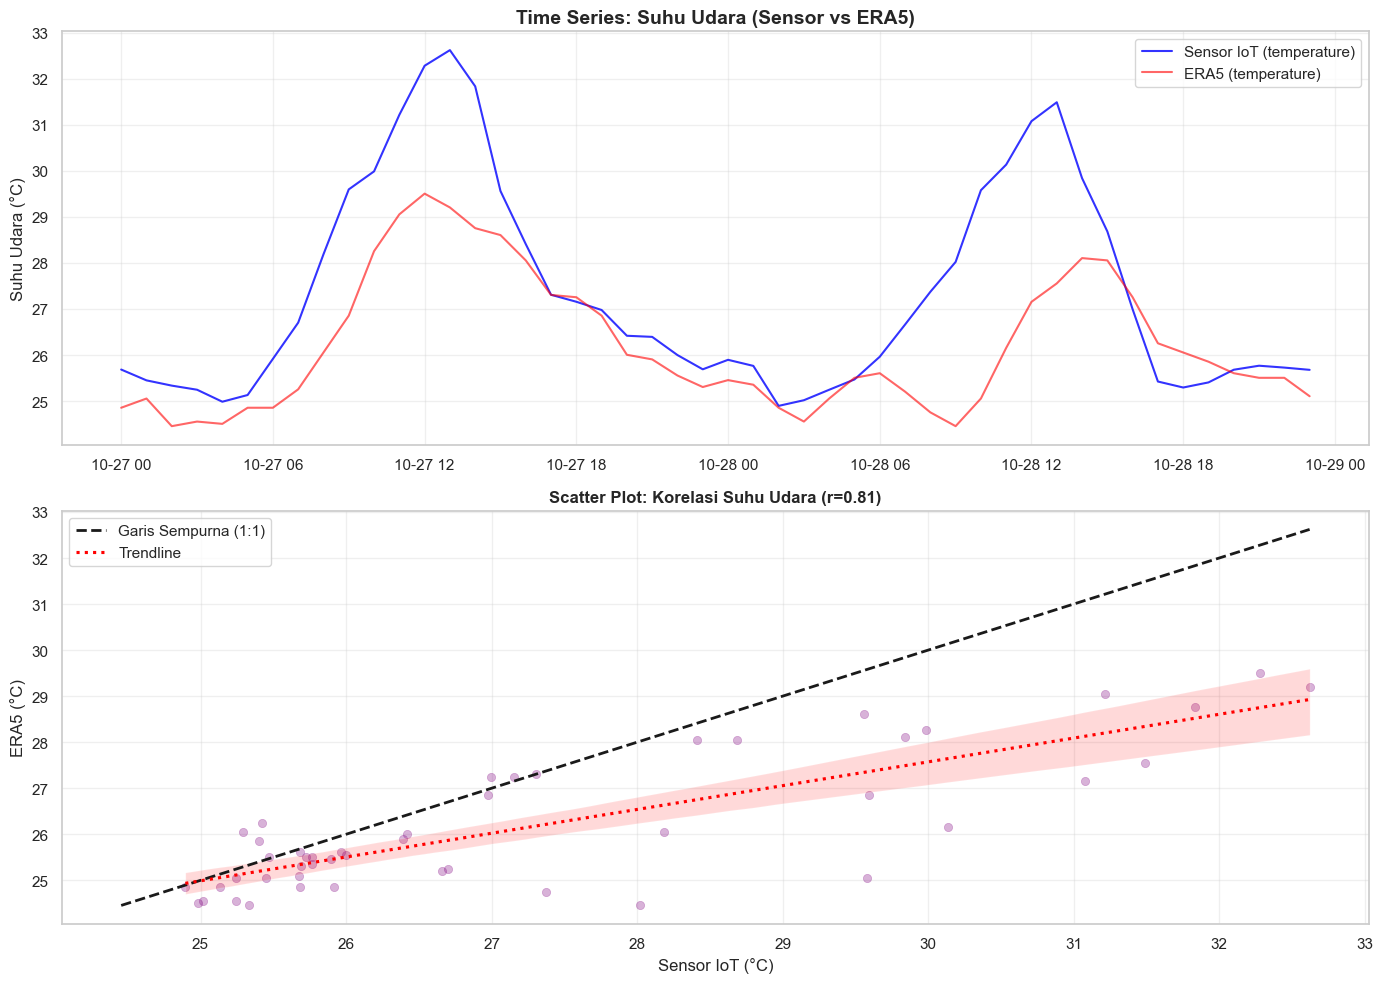


📊 ANALISIS PERBANDINGAN: KELEMBAPAN
📅 Periode: 2025-10-27 00:00:00 s.d 2025-10-28 23:59:59
1. Statistik Error:
   - MAE  : 5.82 %
   - RMSE : 6.95 %
   - Bias Max (Model - Sensor): 9.13 %
   - Bias Min (Model - Sensor): -16.63 %
   - Bias (Rata-rata Selisih): -4.14 %

2. Statistik Hubungan:
   - Pearson (Linear)    : 0.5985
   - Spearman (Ranking)  : 0.5915


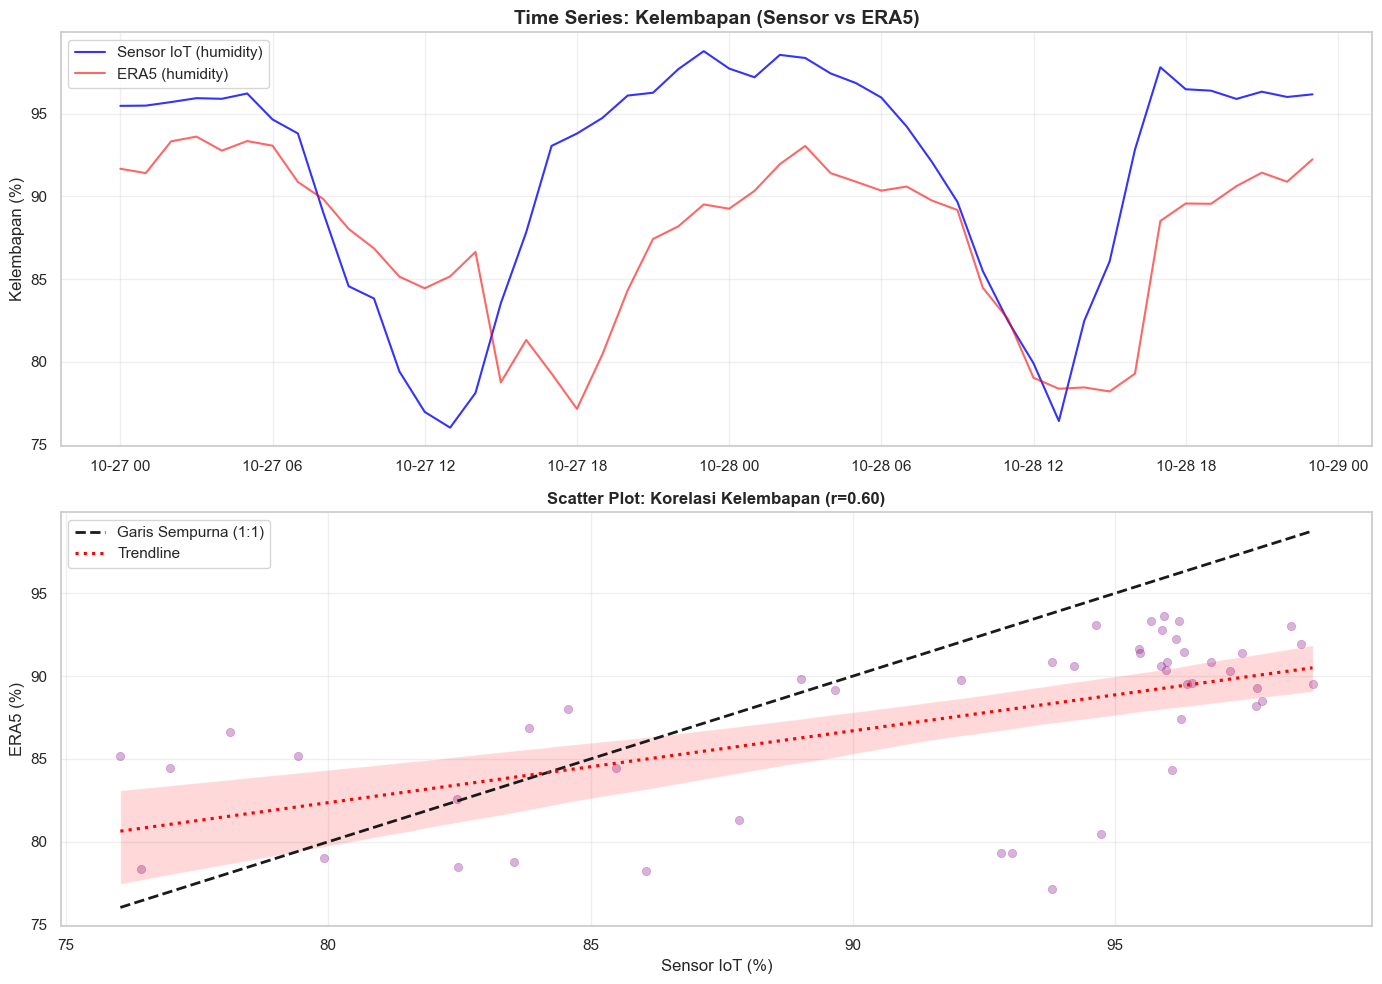


📊 ANALISIS PERBANDINGAN: TEKANAN UDARA
📅 Periode: 2025-10-27 00:00:00 s.d 2025-10-28 23:59:59
1. Statistik Error:
   - MAE  : 1.88 hPa
   - RMSE : 1.98 hPa
   - Bias Max (Model - Sensor): -0.61 hPa
   - Bias Min (Model - Sensor): -3.40 hPa
   - Bias (Rata-rata Selisih): -1.88 hPa

2. Statistik Hubungan:
   - Pearson (Linear)    : 0.8565
   - Spearman (Ranking)  : 0.8620


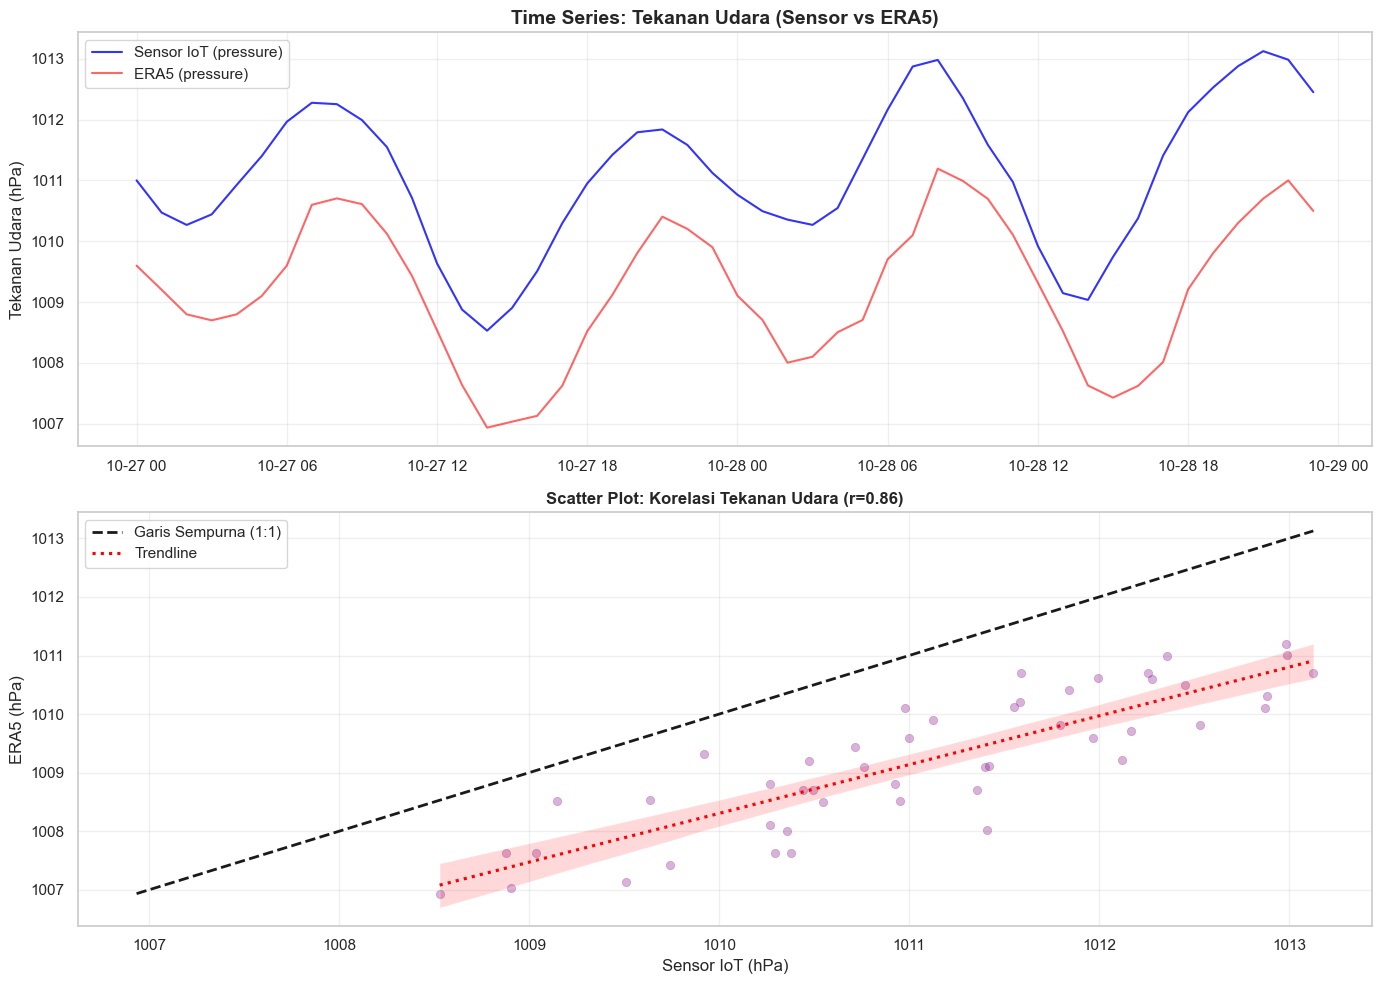


📊 ANALISIS PERBANDINGAN: CURAH HUJAN
📅 Periode: 2025-10-27 00:00:00 s.d 2025-10-28 23:59:59
1. Statistik Error:
   - MAE  : 6.16 mm/jam
   - RMSE : 13.37 mm/jam
   - Bias Max (Model - Sensor): 18.54 mm/jam
   - Bias Min (Model - Sensor): -67.24 mm/jam
   - Bias (Rata-rata Selisih): -2.83 mm/jam

2. Statistik Hubungan:
   - Pearson (Linear)    : 0.0742
   - Spearman (Ranking)  : -0.0341


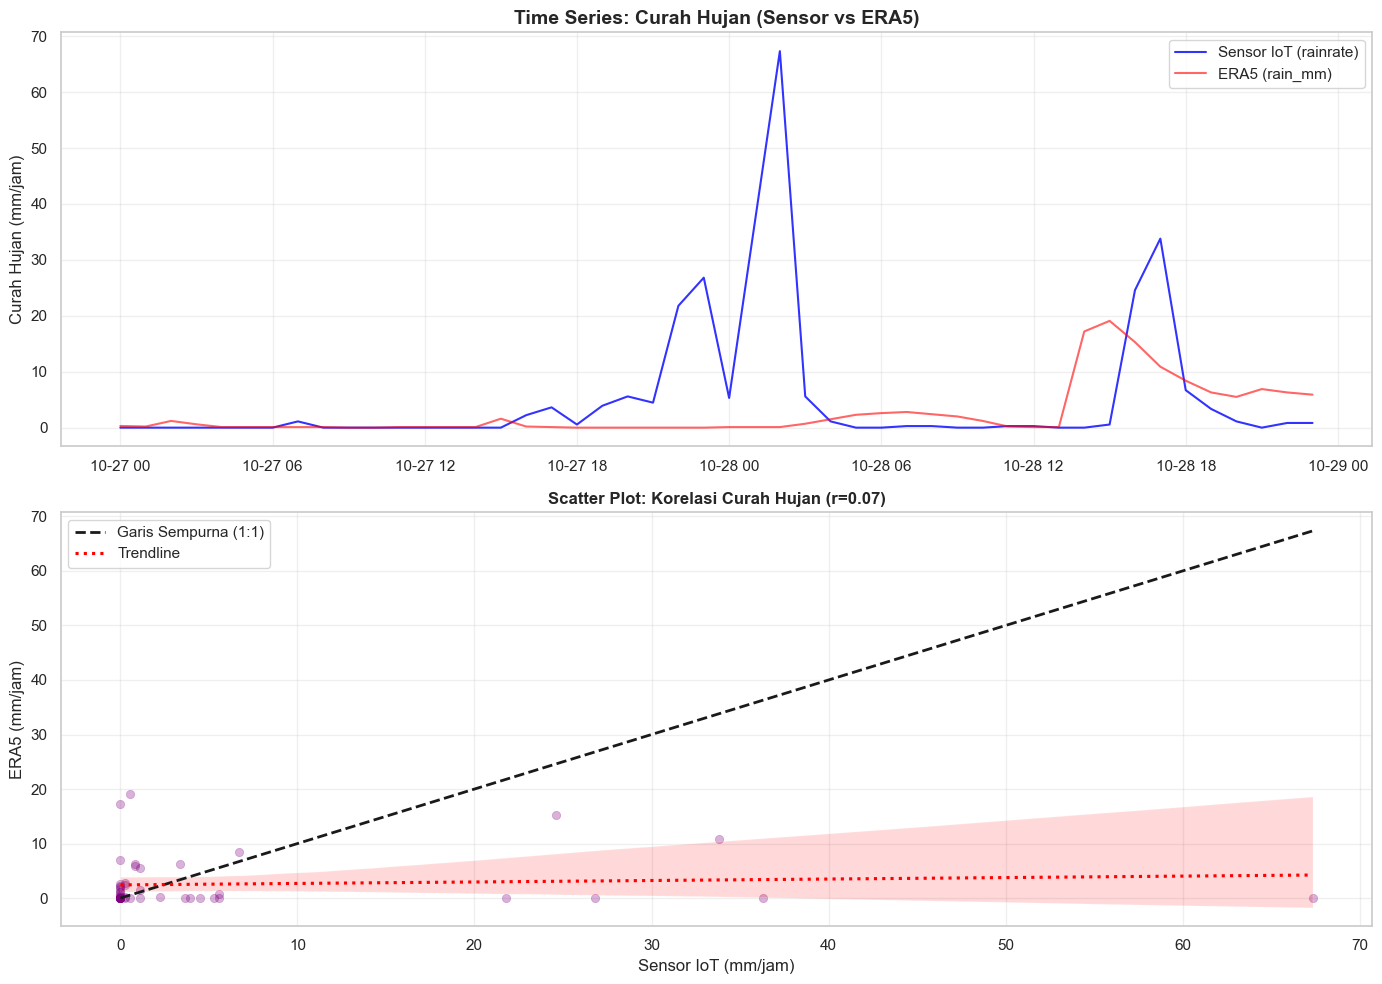

In [45]:
start_time = '2025-10-27 00:00:00'
end_time = '2025-10-28 23:59:59'
# 1. Tanpa filter waktu (menampilkan semua data seperti sebelumnya)
bandingkan_variabel('temperature', 'temperature', 'Suhu Udara', '°C', start_time=start_time, end_time=end_time)

# 2. Menggunakan start_time (Contoh: Membuang outlier di bulan Maret, mulai analisis dari April 2025)
bandingkan_variabel('humidity', 'humidity', 'Kelembapan', '%', start_time=start_time, end_time=end_time)

# 3. Menggunakan start_time dan end_time (Contoh: Analisis spesifik 1 bulan saja)
bandingkan_variabel('pressure', 'pressure', 'Tekanan Udara', 'hPa', start_time=start_time, end_time=end_time)

# 4. Filter spesifik dengan jam (Contoh: Badai ekstrem dalam 2 hari)
bandingkan_variabel('rainrate', 'rain_mm', 'Curah Hujan', 'mm/jam', start_time=start_time, end_time=end_time)